## 1. Imports and settings

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Detect whether the file is being executed from the repository root or from a
# ``notebooks`` directory. This keeps all output paths inside the project.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

for directory in [DATA_DIR, RESULTS_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# Tell Scanpy where to cache downloaded datasets and configure plot appearance.
sc.settings.datasetdir = DATA_DIR
sc.settings.figdir = FIGURE_DIR
sc.settings.verbosity = 2
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white",
    frameon=False,
)


def save_and_show(filename: str) -> None:
    """Save the current Matplotlib figure and then display it."""
    figure = plt.gcf()
    figure.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


print("Software versions used for this analysis:")
sc.logging.print_header()

/tmp/ipykernel_16351/3338050232.py:33: FutureWarning: The method set_figure_params is deprecated and will be removed in the future. Use :func:`scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


Software versions used for this analysis:


/home/alejandro/miniconda3/lib/python3.13/site-packages/IPython/core/formatters.py:1036: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  return method(include=include, exclude=exclude)


Package,Version
matplotlib,3.10.8
numpy,2.4.2
pandas,2.3.3
scanpy,1.12.3
seaborn,0.13.2
Component,Info
Python,"3.13.11 | packaged by Anaconda, Inc. | (main, Dec 10 2025, 21:28:48) [GCC 14.3.0]"
OS,Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
CPU,"16/16 logical CPU cores, x86_64"
GPU,No GPU found


# 2. Load raw PBMC 3k count matrix

try downloading from url
https://exampledata.scverse.org/scanpy/pbmc3k_raw.h5ad
... this may take a while but only happens once


/home/alejandro/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 5.58M/5.58M [00:00<00:00, 42.1MB/s]



Raw AnnData object:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
Number of cells: 2,700
Number of genes: 32,738

First rows of cell metadata (adata.obs):


""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1



First rows of gene metadata (adata.var):


,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945



A small dense view of the otherwise sparse count matrix:


,0,1,2,3,4
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


normalizing counts per cell
    finished (0:00:04)


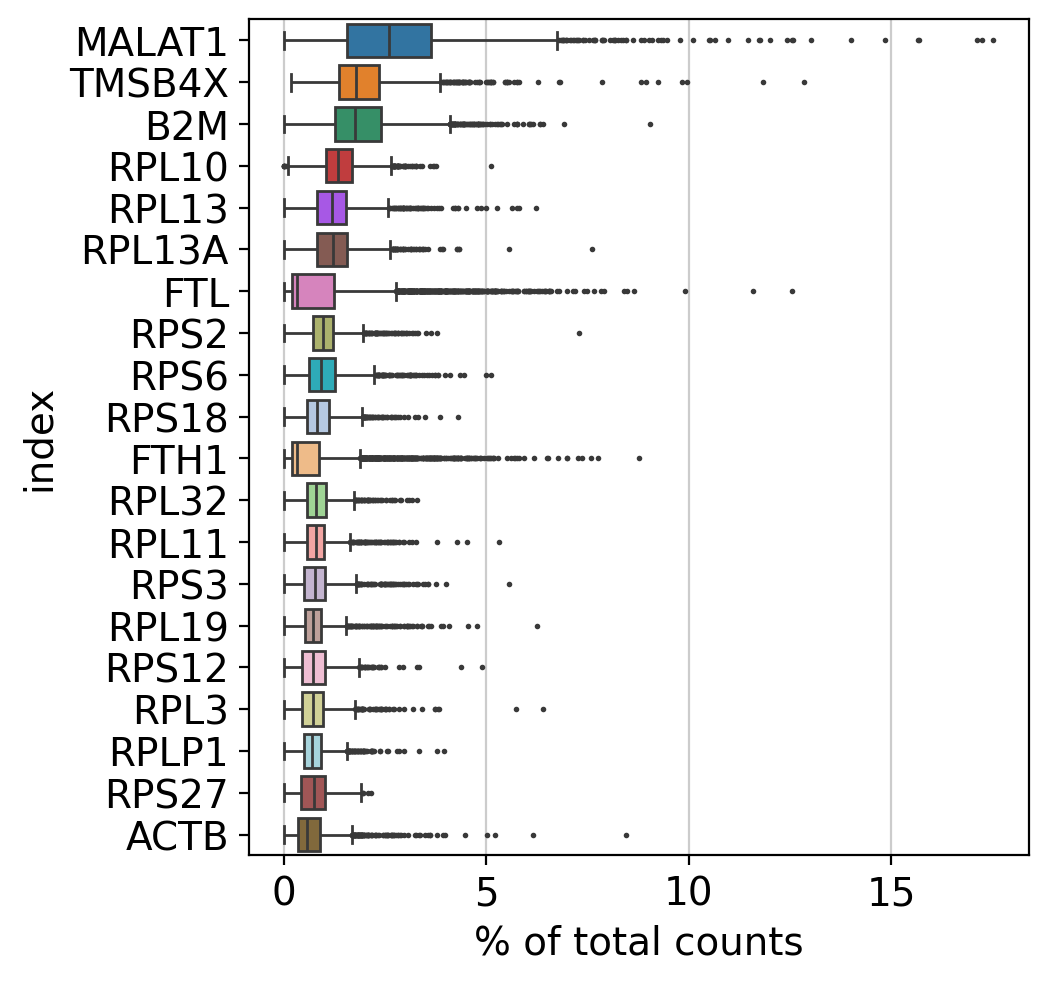

In [2]:
# Rows are cell barcodes, columns are genes and values are UMI counts. 
# The matrix is sparse because most genes are not detected in most cells.
adata = sc.datasets.pbmc3k()

# If a symbol appears more than once, this method adds a suffix so that every variable name is unique.
adata.var_names_make_unique()

print("\nRaw AnnData object:")
print(adata)
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")

print("\nFirst rows of cell metadata (adata.obs):")
display(adata.obs.head())

print("\nFirst rows of gene metadata (adata.var):")
display(adata.var.head())

print("\nA small dense view of the otherwise sparse count matrix:")
display(pd.DataFrame(adata.X[:5, :5].toarray()))


# Plot the genes contributing the largest fraction of counts in individual cells.
sc.pl.highest_expr_genes(adata, n_top=20, show=False)
save_and_show("01_highest_expressed_genes.png")


# 3. Calculate quality-control metrics before filterin


Quality-control summary before filtering:


,count,mean,std,min,25%,50%,75%,max
total_counts,2700.0,2366.900391,1094.262085,548.000000,1757.750000,2197.000000,2763.000000,15844.000000
n_genes_by_counts,2700.0,846.994074,282.104964,212.000000,690.000000,817.000000,953.250000,3422.000000
pct_counts_mt,2700.0,2.215132,1.165438,0.000000,1.536238,2.029639,2.640218,22.569027
pct_counts_ribo,2700.0,34.949211,10.215296,1.055966,26.332963,36.769516,43.353328,59.441711


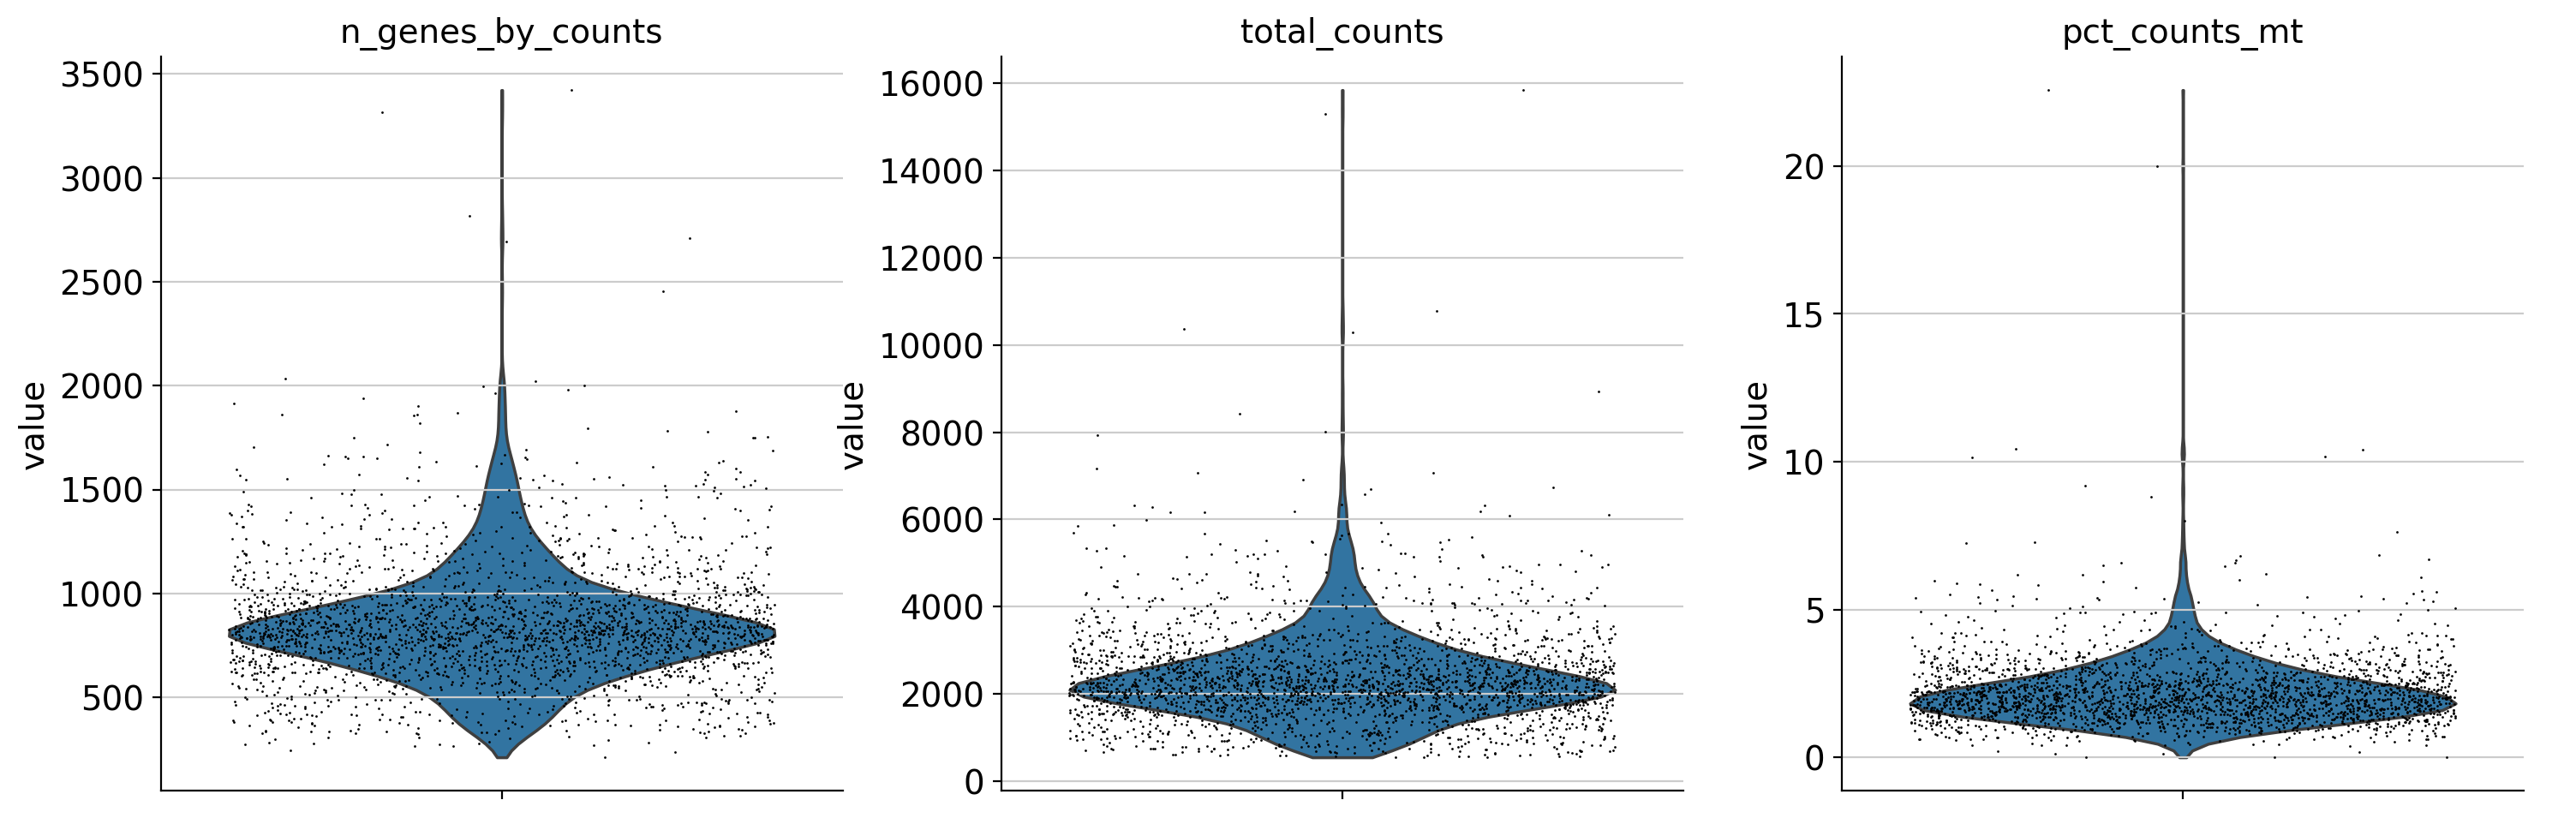

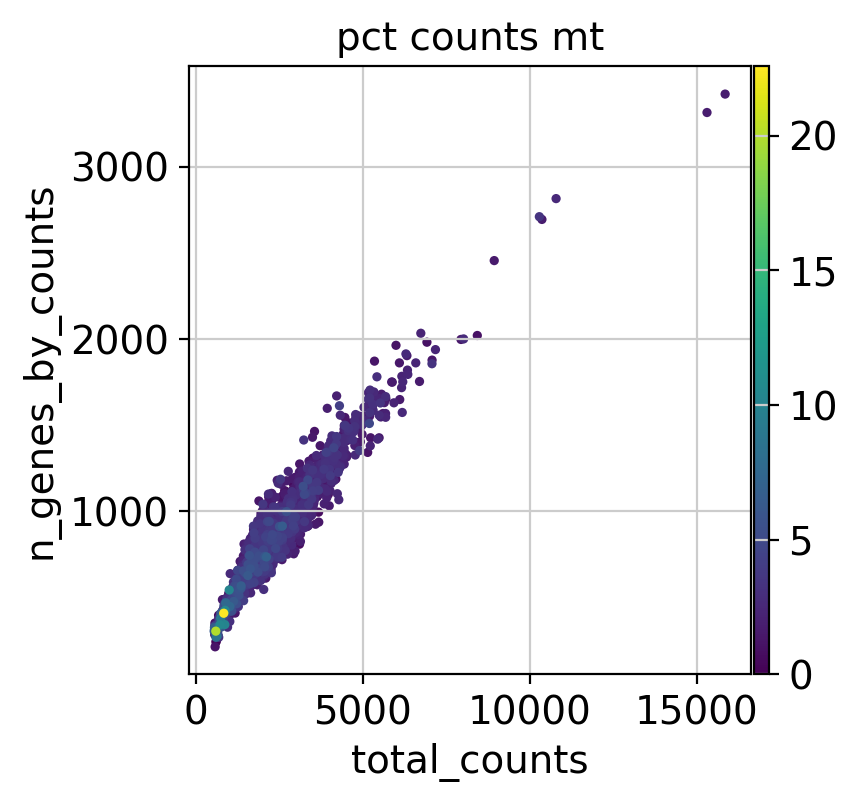

In [3]:
# Calculate the fraction of each cell's counts assigned to mitochondrial and ribosomal genes.
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=True,
    inplace=True,
)

QC_COLUMNS = [
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
]

print("\nQuality-control summary before filtering:")
display(adata.obs[QC_COLUMNS].describe().T)


sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
save_and_show("02_qc_violin_before_filtering.png")


# Looking at metrics jointly is more informative than inspecting each one alone.
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    show=False,
)
save_and_show("03_qc_counts_vs_genes.png")

# 4. Filter low-quality cells and uninformative gene


Cell-level QC decision:


Pass    2638
Name: count, dtype: int64


Filtered AnnData object:
AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
Removed 0 cells and 0 genes.

Quality-control summary after filtering:


,count,mean,std,min,25%,50%,75%,max
total_counts,2638.0,2371.025391,990.121094,556.000000,1779.250000,2213.000000,2766.000000,8875.000000
n_genes_by_counts,2638.0,848.606899,262.727587,212.000000,699.000000,819.000000,954.000000,2413.000000
pct_counts_mt,2638.0,2.116608,0.843120,0.000000,1.520267,2.010702,2.591085,4.995375
pct_counts_ribo,2638.0,35.078594,10.231339,1.061571,26.396853,36.925241,43.512506,59.441711


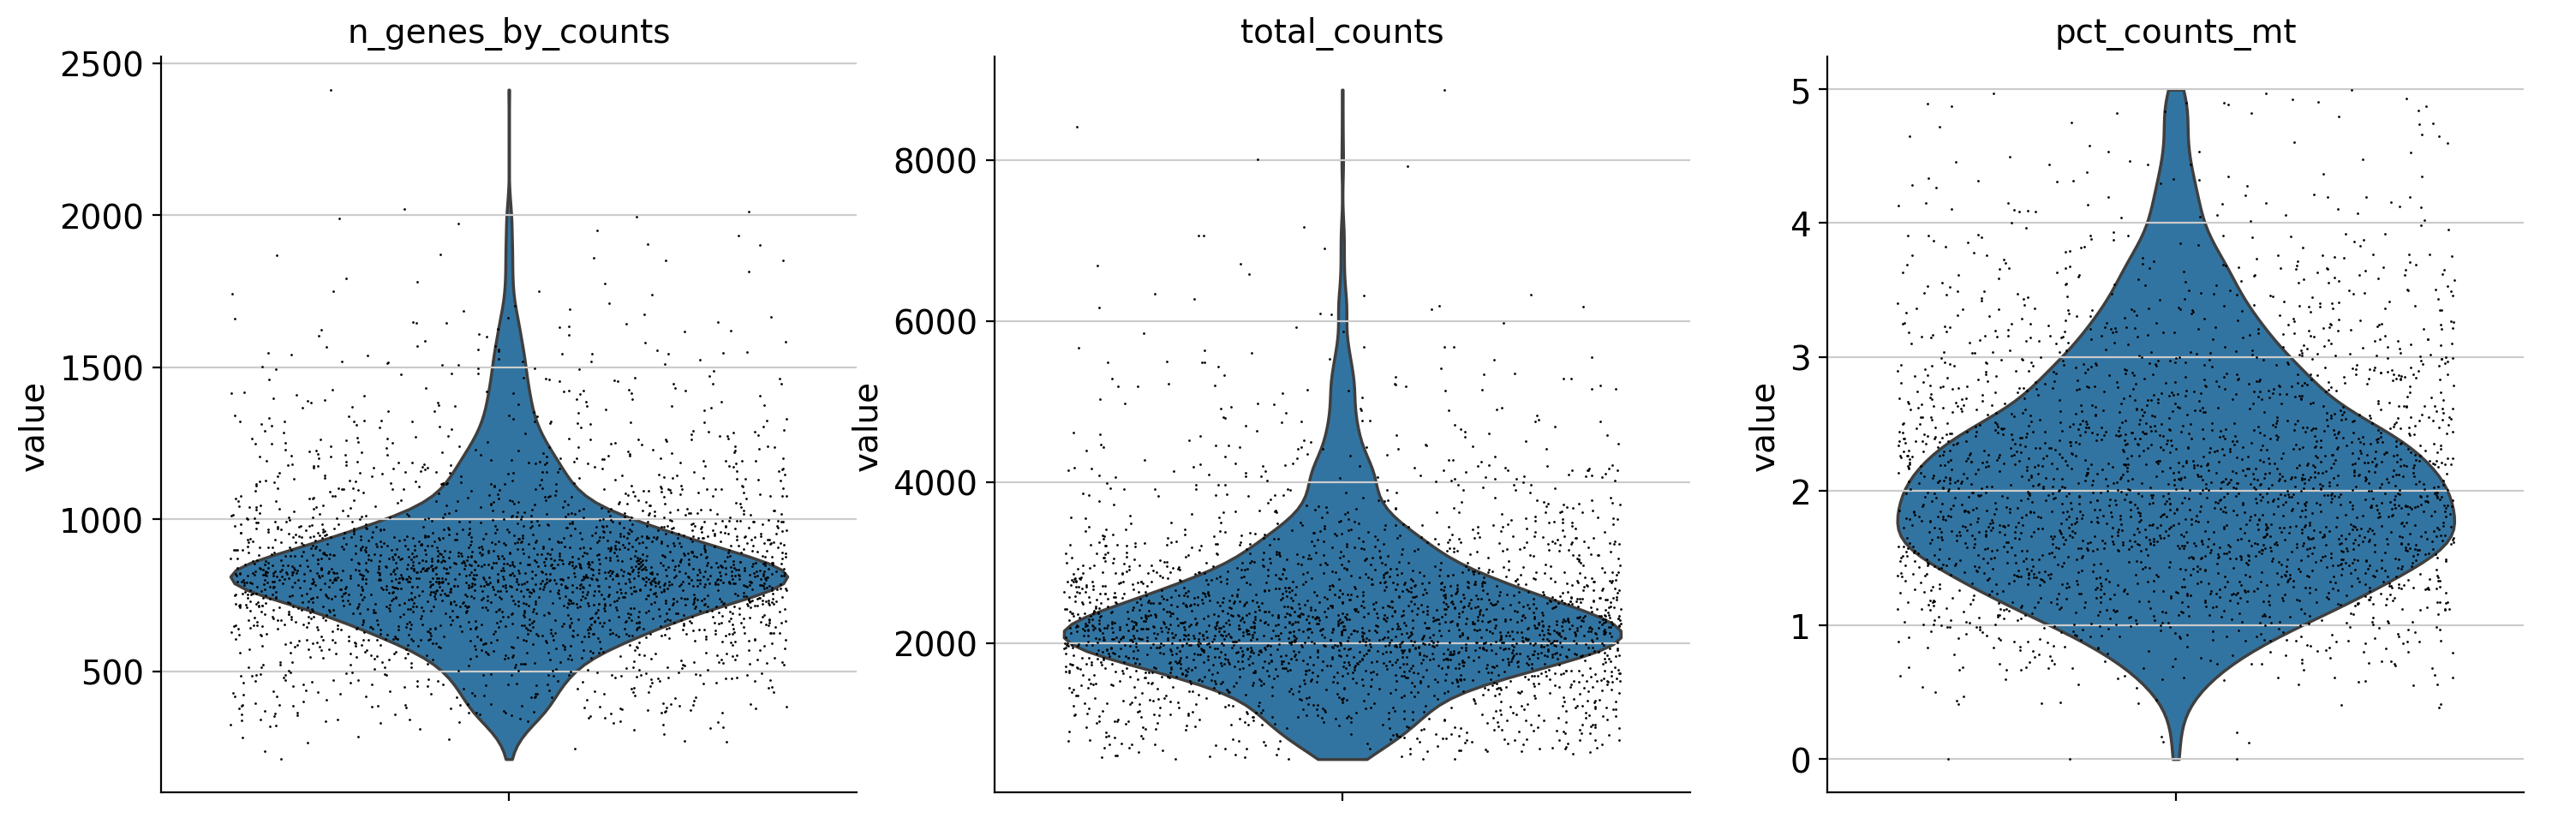

In [5]:
MIN_GENES = 200
MAX_GENES = 2500
MAX_MITOCHONDRIAL_PERCENT = 5.0
MIN_CELLS_PER_GENE = 3

number_of_cells_before_filtering = adata.n_obs
number_of_genes_before_filtering = adata.n_vars

cell_passes_qc = (
    (adata.obs["n_genes_by_counts"] >= MIN_GENES)
    & (adata.obs["n_genes_by_counts"] < MAX_GENES)
    & (adata.obs["pct_counts_mt"] < MAX_MITOCHONDRIAL_PERCENT)
)

print("\nCell-level QC decision:")
display(cell_passes_qc.value_counts().rename(index={True: "Pass", False: "Fail"}))

adata = adata[cell_passes_qc].copy()

# Remove genes detected in fewer than three retained cells.
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

# Recalculate QC values so that post-filtering summaries exactly match the retained cell-by-gene matrix.
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo"],
    percent_top=None,
    log1p=True,
    inplace=True,
)

print("\nFiltered AnnData object:")
print(adata)
print(
    f"Removed {number_of_cells_before_filtering - adata.n_obs:,} cells and "
    f"{number_of_genes_before_filtering - adata.n_vars:,} genes."
)

print("\nQuality-control summary after filtering:")
display(adata.obs[QC_COLUMNS].describe().T)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
save_and_show("04_qc_violin_after_filtering.png")

# 5. Detect potential doublets with Scruble

Running Scrublet
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.23
Detected doublet rate = 1.4%
Estimated detectable doublet fraction = 37.8%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 3.8%
    Scrublet finished (0:00:08)

Scrublet calls:


predicted_doublet
False    2600
True       38
Name: count, dtype: int64

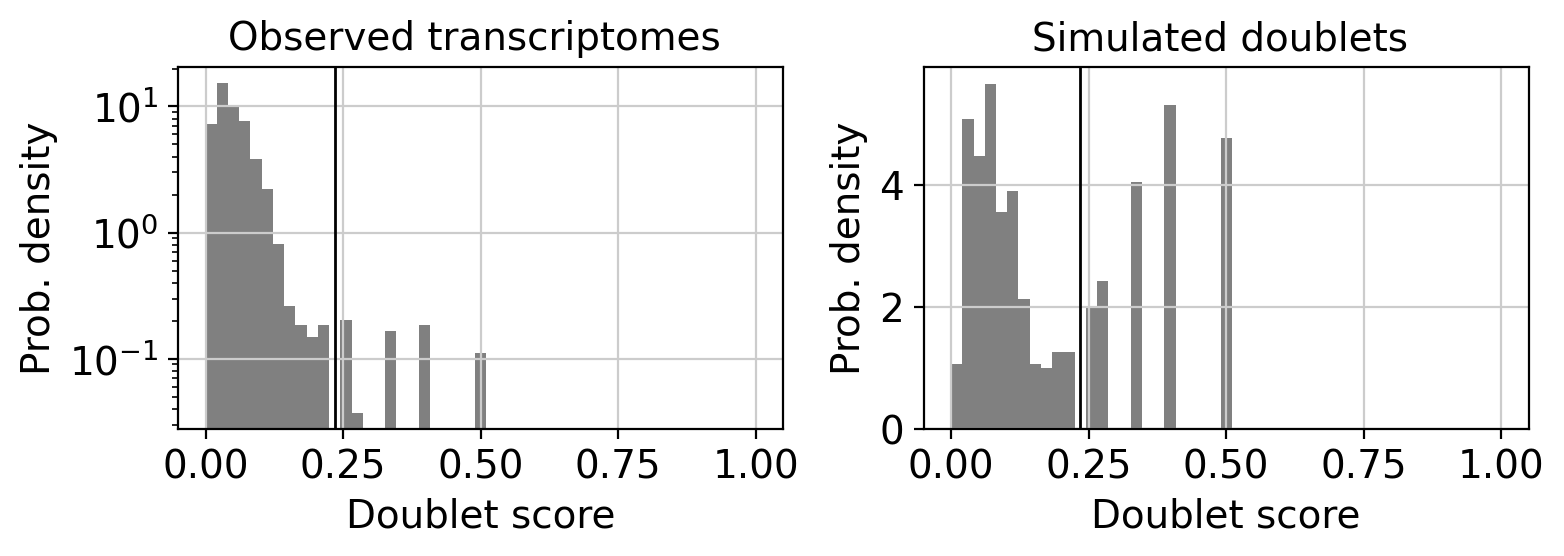

Predicted doublets were retained for the first analysis pass. Their scores will be inspected on the UMAP.


In [ ]:
# Scrublet simulates artificial doublets and compares them with observed transcriptomes.
# It should receive raw counts, which is why this step is performed before normalization and log transformation.
sc.pp.scrublet(
    adata,
    expected_doublet_rate=0.05,
    random_state=RANDOM_STATE,
)

print("\nScrublet calls:")
display(adata.obs["predicted_doublet"].value_counts())

sc.pl.scrublet_score_distribution(adata, show=False)
save_and_show("05_scrublet_score_distribution.png")


# An algorithmic doublet call is evidence, not ground truth. Keeping the calls as
# metadata during the first pass lets us inspect whether high scores form strange
# clusters on the UMAP. Change this flag only after reviewing the diagnostics.
REMOVE_PREDICTED_DOUBLETS = False

if REMOVE_PREDICTED_DOUBLETS:
    number_before_doublet_filtering = adata.n_obs
    adata = adata[~adata.obs["predicted_doublet"]].copy()
    print(
        f"Removed {number_before_doublet_filtering - adata.n_obs:,} "
        "Scrublet-predicted doublets."
    )
else:
    print(
        "Predicted doublets were retained for the first analysis pass. "
        "Their scores will be inspected on the UMAP."
    )

#  6. Preserve raw counts, normalize library size and log-transform expression

In [7]:
# Store the unmodified UMI matrix in a named layer. This is the matrix needed for
# count-based approaches such as pseudobulk analysis. Do this before modifying X.
adata.layers["counts"] = adata.X.copy()


# Different cells can have different sequencing depths. ``normalize_total``
# scales every cell so that its expression values sum to 10,000. This makes cells
# more comparable while preserving relative expression within each cell.
sc.pp.normalize_total(adata, target_sum=1e4)


# Single-cell counts are highly right-skewed. ``log1p`` calculates log(1 + x),
# reducing the influence of very highly expressed genes while keeping zeros at 0.
sc.pp.log1p(adata)


# ``adata.raw`` is a snapshot of the full, normalized and log-transformed gene
# matrix. Despite its name, it is not the original UMI matrix; those counts are in
# ``adata.layers['counts']``. The raw snapshot lets marker testing and plotting use
# every gene even when dimensionality reduction uses only highly variable genes.
adata.raw = adata

print("\nData representations after normalization:")
print("adata.X: normalized and log-transformed expression")
print("adata.layers['counts']: original UMI counts")
print("adata.raw: full normalized and log-transformed expression snapshot")

normalizing counts per cell
    finished (0:00:00)

Data representations after normalization:
adata.X: normalized and log-transformed expression
adata.layers['counts']: original UMI counts
adata.raw: full normalized and log-transformed expression snapshot


# 7. Select highly variable genes

extracting highly variable genes
    finished (0:00:00)

Selected 2,000 highly variable genes.


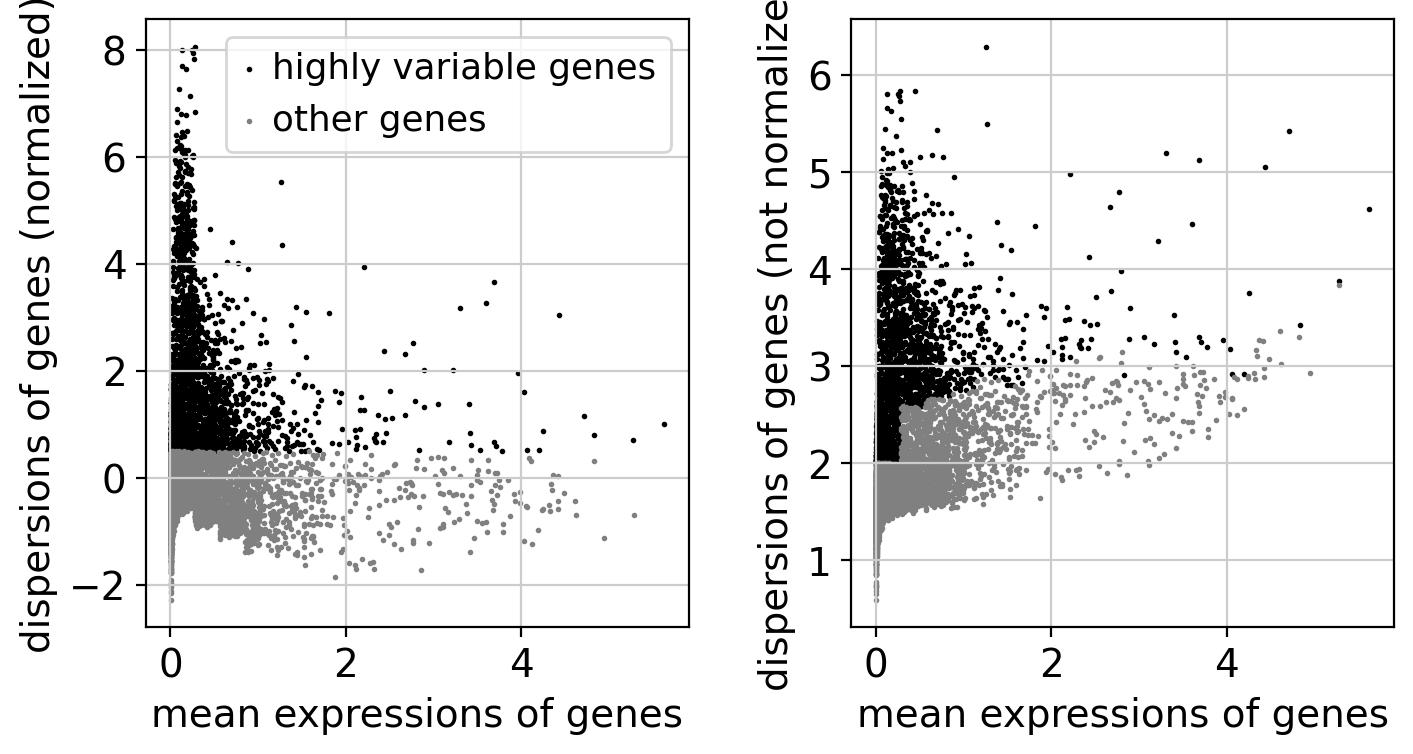

In [8]:
# Genes vary for technical and biological reasons. Highly variable gene (HVG)
# selection identifies genes that carry more information than expected for their
# mean expression. Restricting PCA to these genes reduces noise and computation.
# The ``seurat`` flavor expects normalized, log-transformed data.
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat",
)

number_of_hvgs = int(adata.var["highly_variable"].sum())
print(f"\nSelected {number_of_hvgs:,} highly variable genes.")

sc.pl.highly_variable_genes(adata, show=False)
save_and_show("06_highly_variable_genes.png")


# We intentionally do not physically delete non-HVG genes. PCA will use the HVG
# mask, while annotation and marker discovery can still access the full gene set.

# 8. Principal component analysis

computing PCA
    with n_comps=50
    finished (0:00:00)


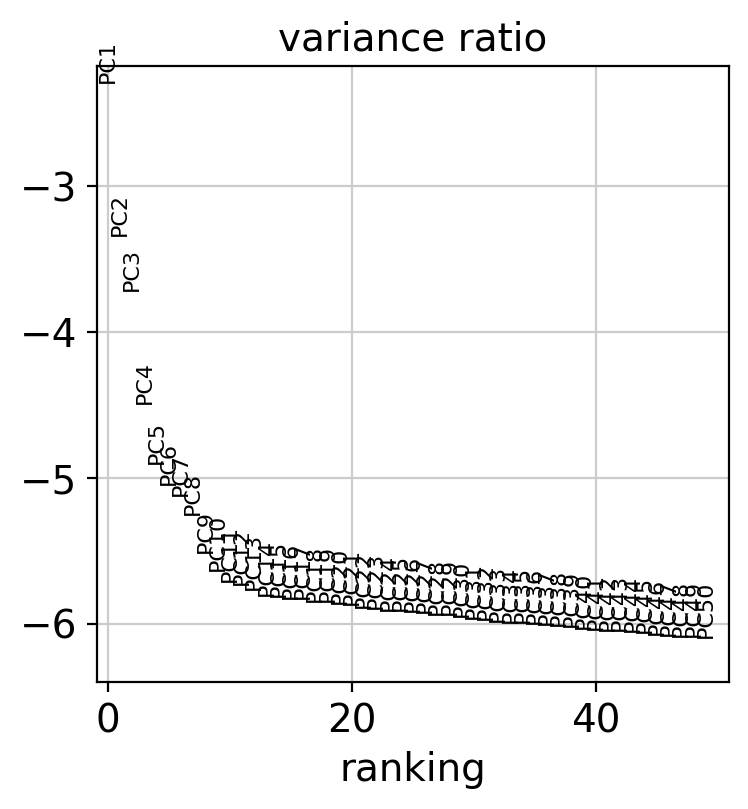

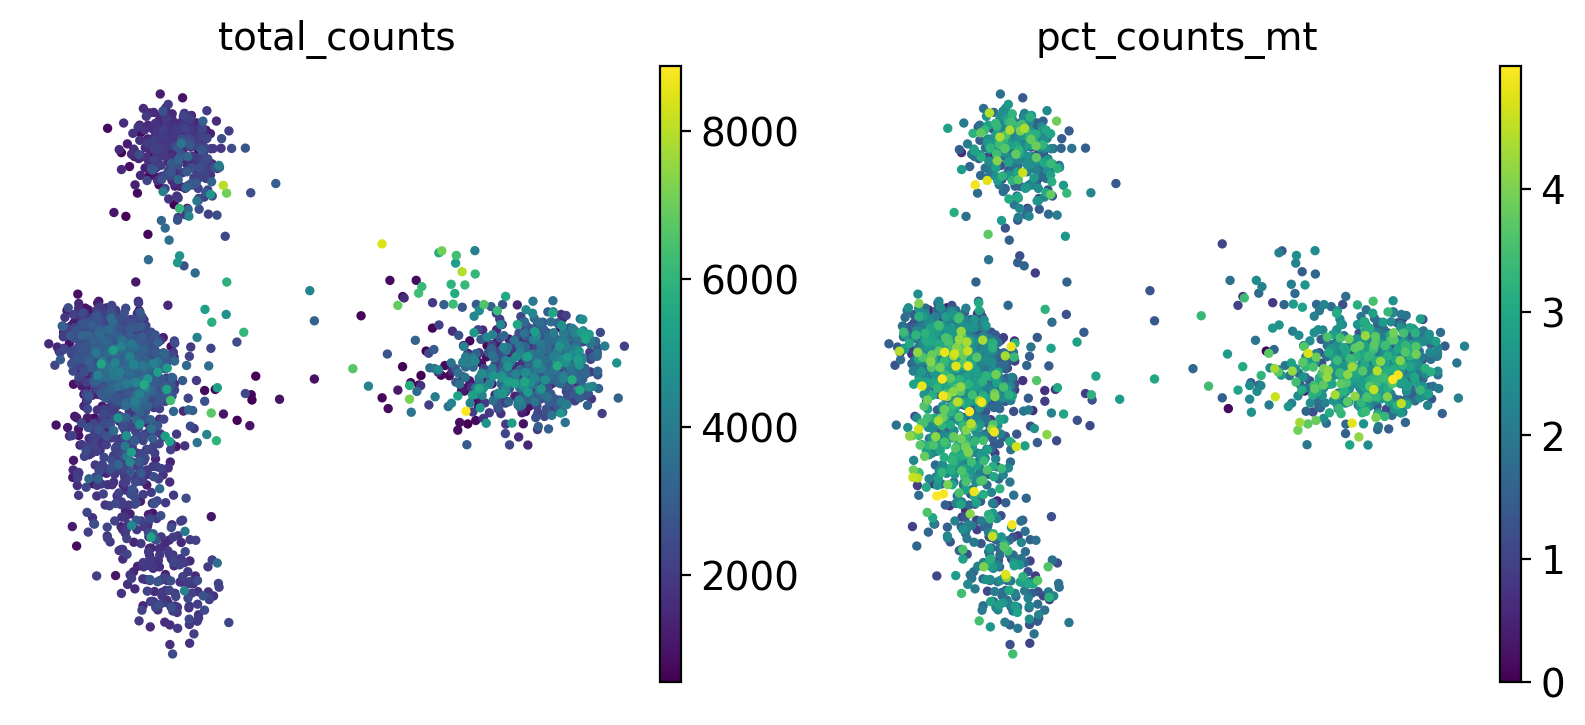

In [9]:
# PCA converts thousands of correlated gene-expression variables into a smaller
# number of orthogonal components. Each component captures one axis of variation.
# Scanpy stores cell coordinates in ``adata.obsm['X_pca']`` and gene loadings in
# ``adata.varm['PCs']``.
sc.pp.pca(
    adata,
    n_comps=50,
    mask_var="highly_variable",
    random_state=RANDOM_STATE,
)


# The variance-ratio plot helps us decide how many PCs contain useful structure.
# There is rarely one objectively correct cutoff. Thirty PCs is a reasonable and
# transparent choice for this small PBMC dataset.
sc.pl.pca_variance_ratio(
    adata,
    n_pcs=50,
    log=True,
    show=False,
)
save_and_show("07_pca_variance_ratio.png")


# Inspect whether technical QC measurements dominate the first components.
sc.pl.pca(
    adata,
    color=["total_counts", "pct_counts_mt"],
    show=False,
)
save_and_show("08_pca_qc_metrics.png")

# 9. Build the neighbor graph and calculate UMAP

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:24)
computing UMAP
    finished (0:00:03)


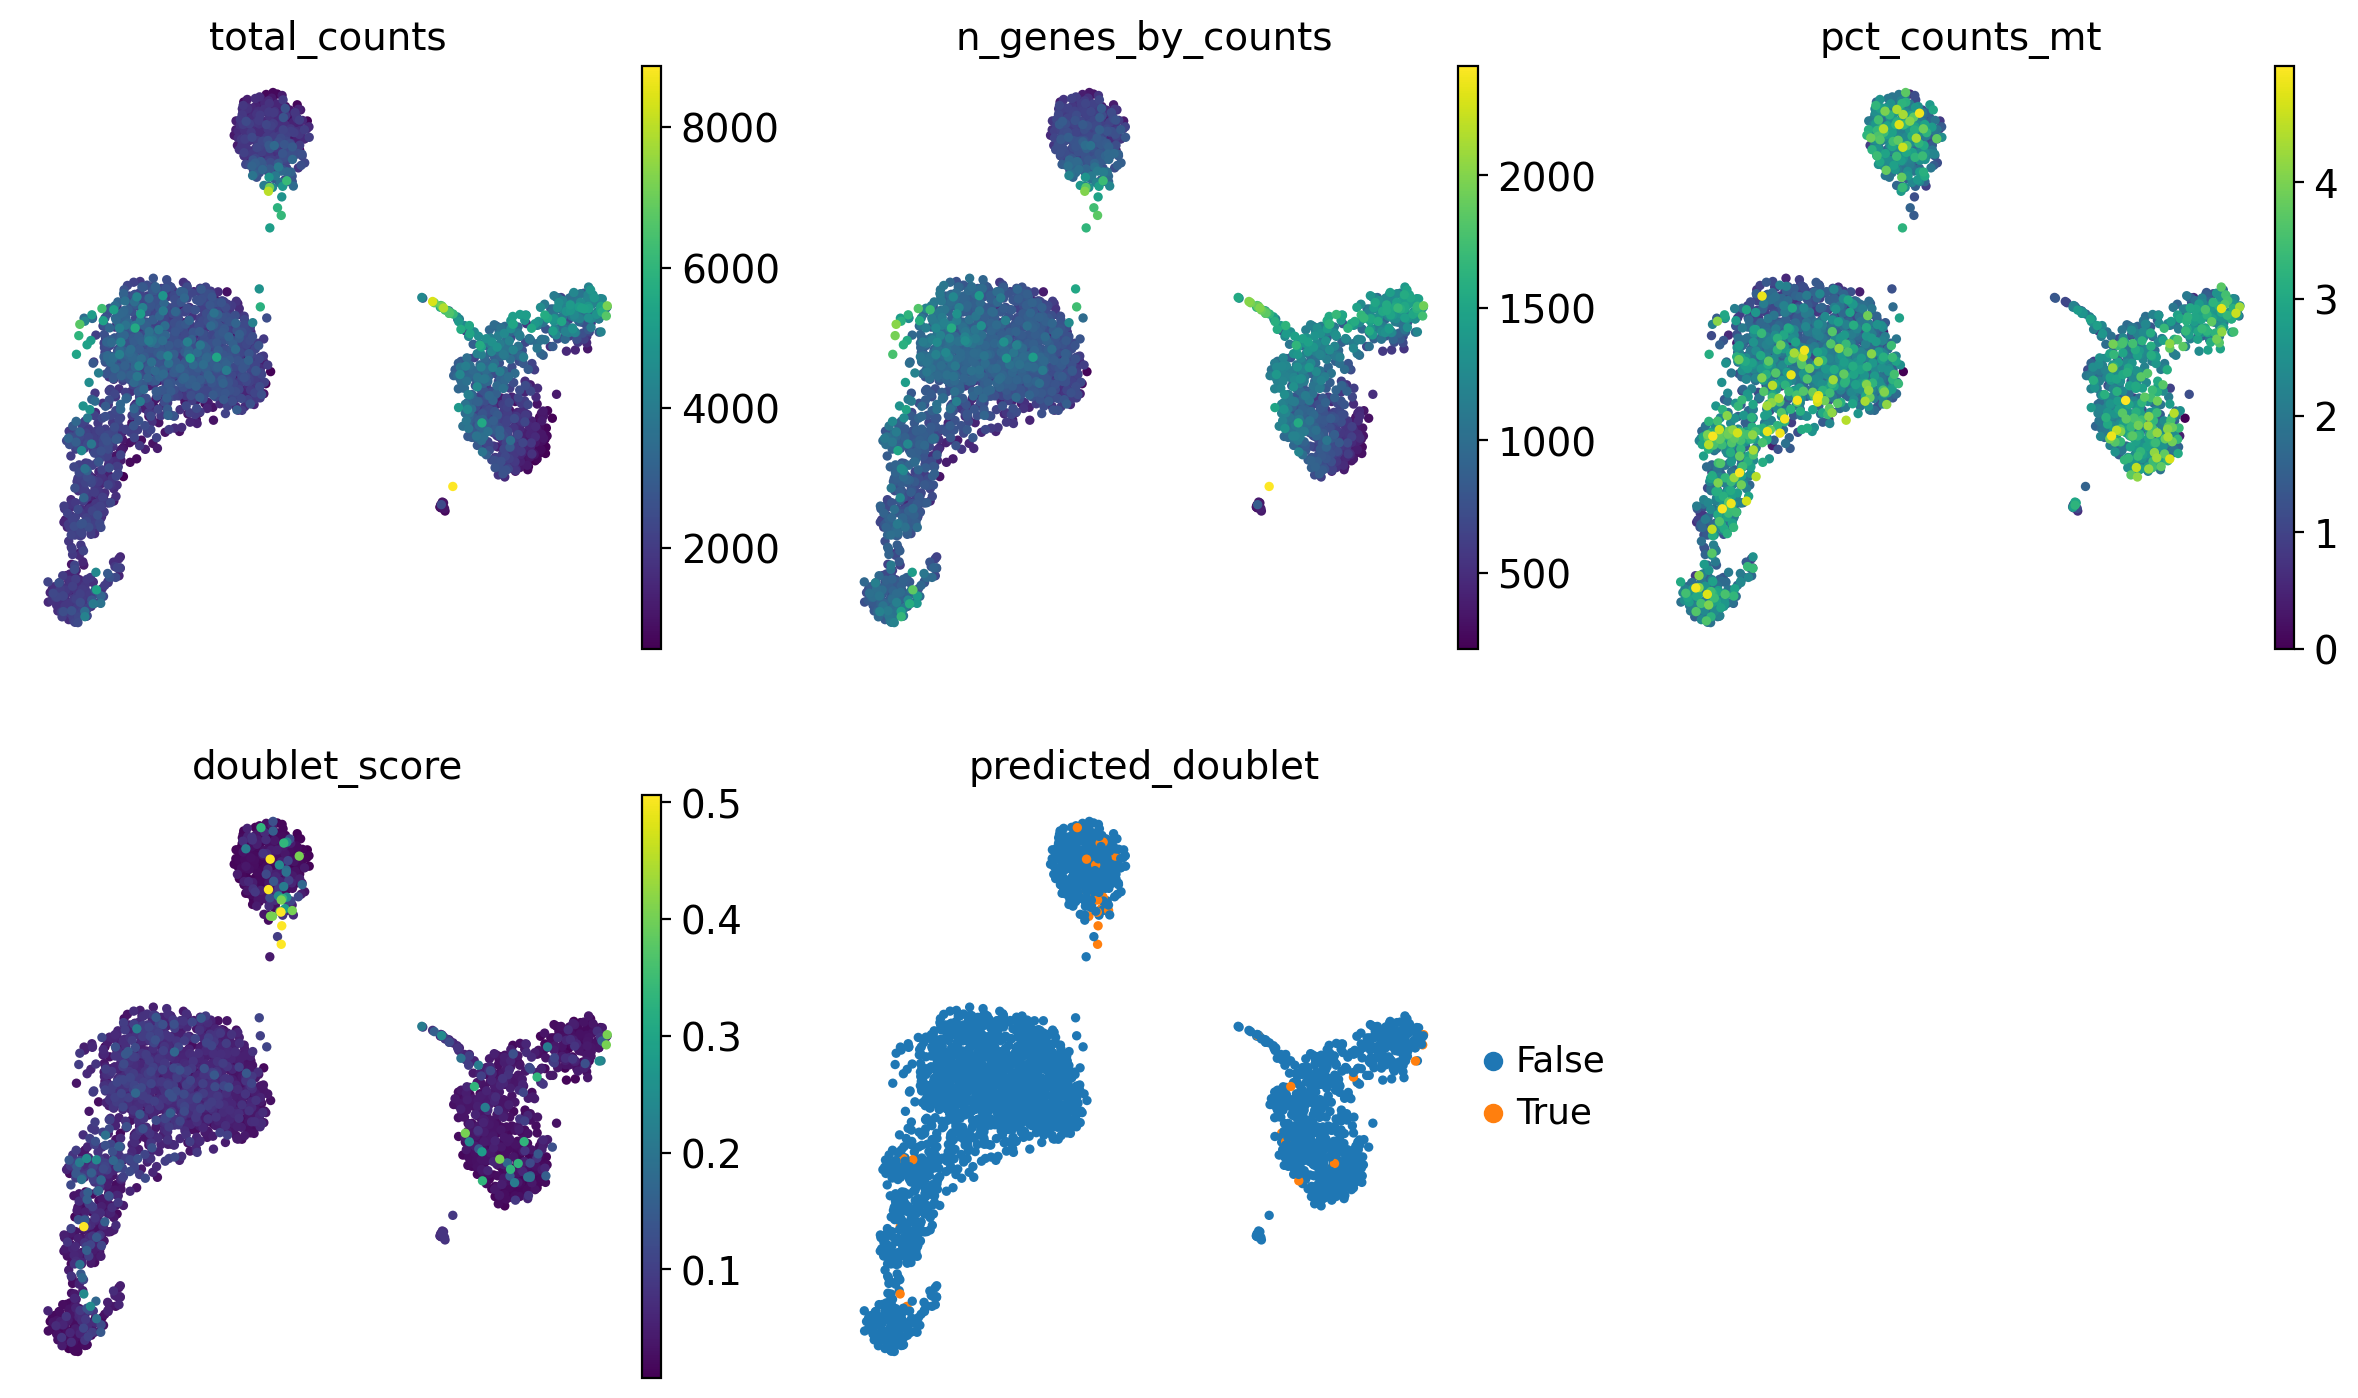

In [10]:
# The neighbor graph connects each cell to transcriptionally similar cells in PCA
# space. ``n_neighbors`` controls how local the representation is, while ``n_pcs``
# determines how many PCA dimensions contribute to the distance calculation.
N_NEIGHBORS = 15
N_PCS_FOR_NEIGHBORS = 30

sc.pp.neighbors(
    adata,
    n_neighbors=N_NEIGHBORS,
    n_pcs=N_PCS_FOR_NEIGHBORS,
    random_state=RANDOM_STATE,
)


# UMAP embeds the neighbor graph in two dimensions for visualization. UMAP axes
# have no direct biological units, and large global distances should not be over-
# interpreted. Local neighborhoods are generally more meaningful than the exact
# shape or orientation of the plot.
sc.tl.umap(
    adata,
    random_state=RANDOM_STATE,
)


# Reassess quality after embedding. A cluster dominated by high mitochondrial
# percentages or high doublet scores may represent a technical artifact.
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
        "doublet_score",
        "predicted_doublet",
    ],
    ncols=3,
    show=False,
)
save_and_show("09_umap_qc_and_doublets.png")

# 10. Cluster cells with the Leiden algorithm

running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)
running Leiden clustering
    finished (0:00:00)


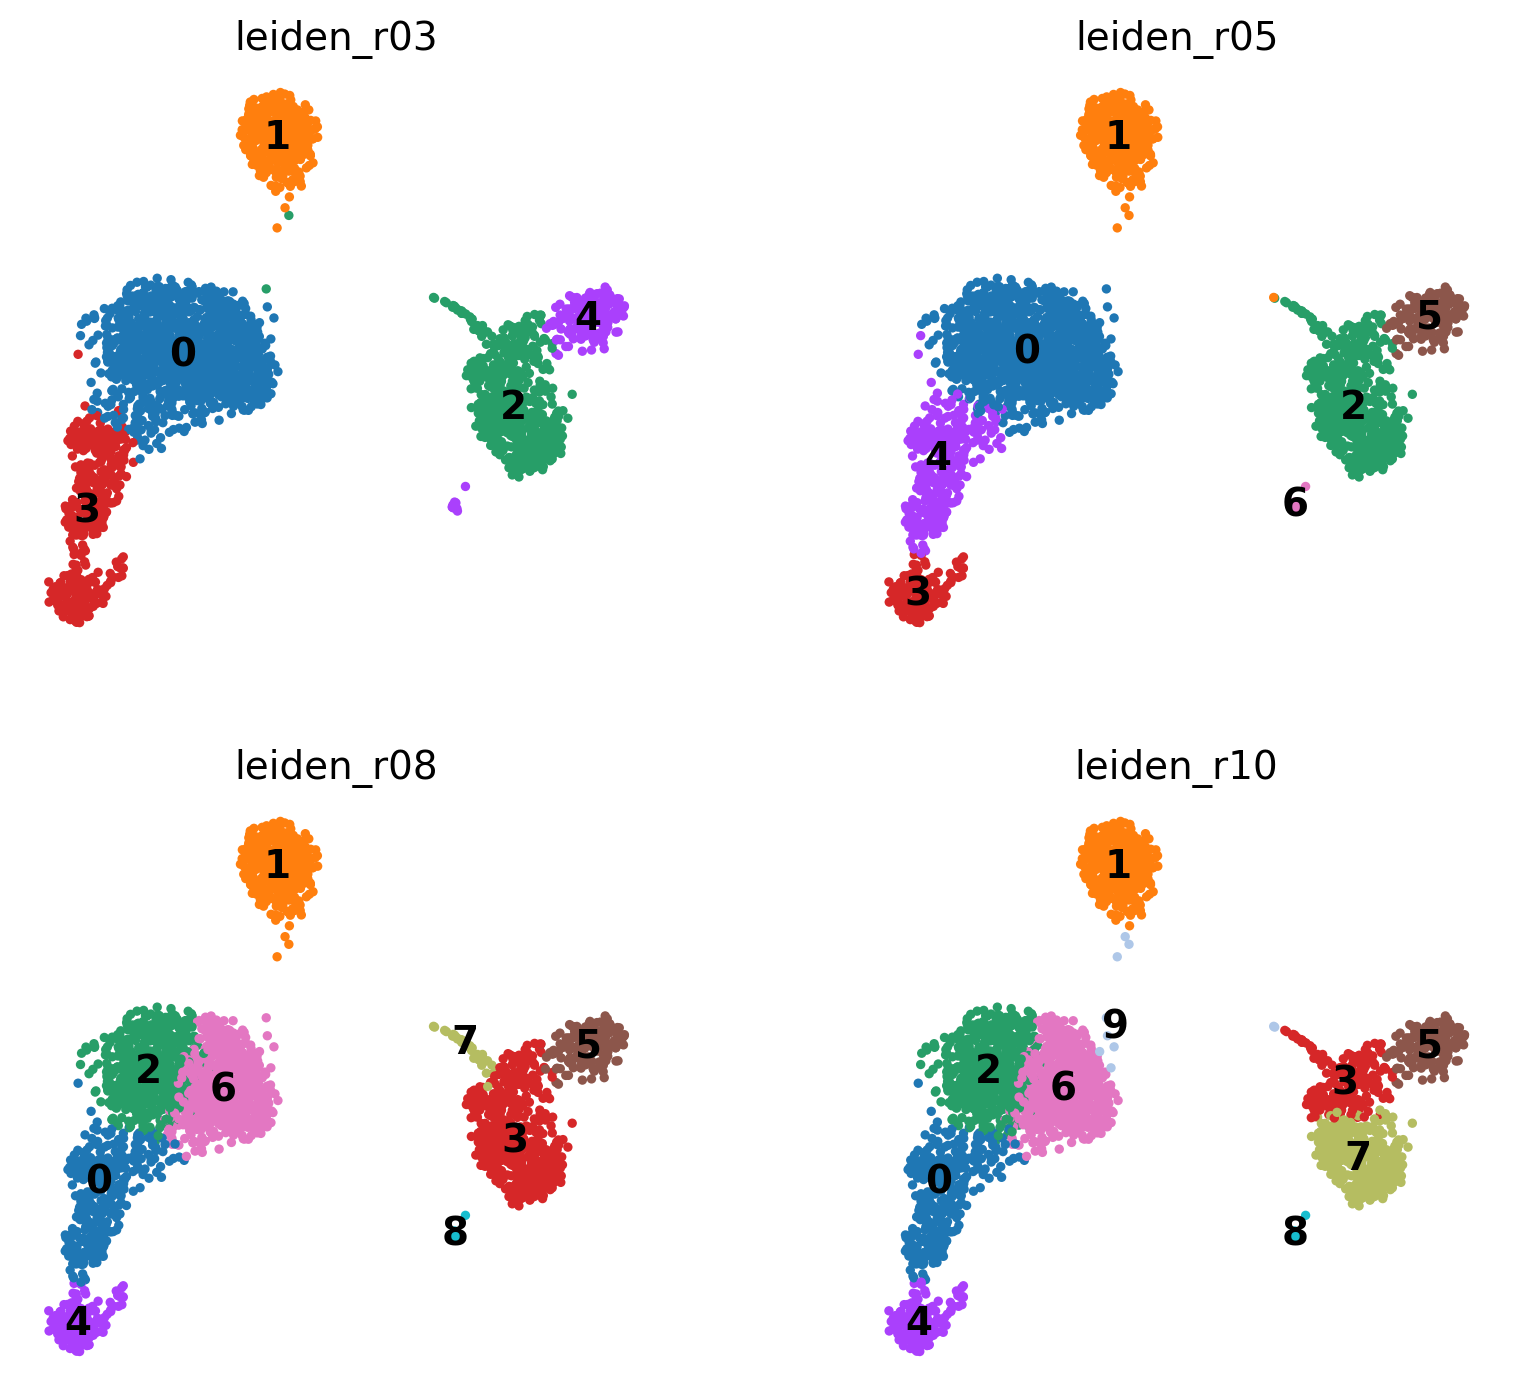


Cells per selected Leiden cluster:


leiden
0    1118
1     346
2     516
3     154
4     335
5     157
6      12
Name: count, dtype: int64

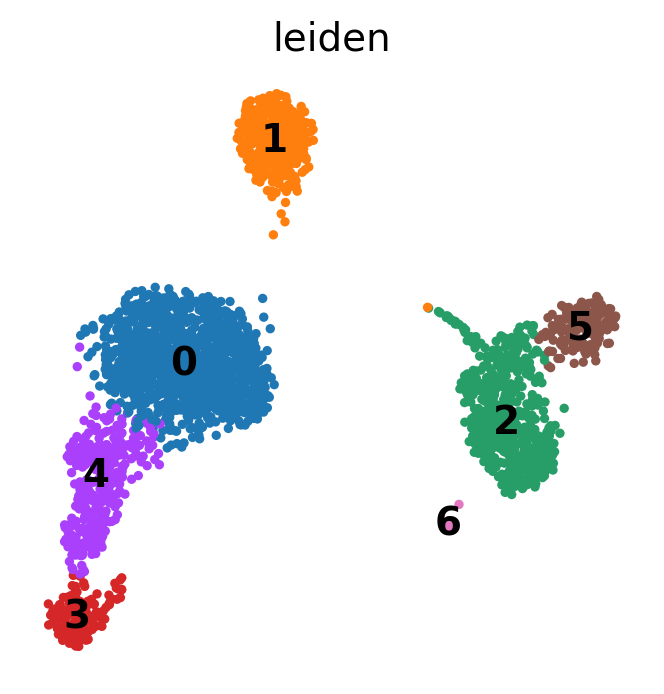

In [11]:
# Leiden finds communities in the neighbor graph. The resolution parameter
# controls granularity: higher values usually produce more clusters. Testing more
# than one resolution is better than treating a single arbitrary value as truth.
LEIDEN_RESOLUTIONS = {
    "leiden_r03": 0.3,
    "leiden_r05": 0.5,
    "leiden_r08": 0.8,
    "leiden_r10": 1.0,
}

for key, resolution in LEIDEN_RESOLUTIONS.items():
    sc.tl.leiden(
        adata,
        resolution=resolution,
        key_added=key,
        flavor="igraph",
        n_iterations=2,
        random_state=RANDOM_STATE,
    )

sc.pl.umap(
    adata,
    color=list(LEIDEN_RESOLUTIONS),
    legend_loc="on data",
    ncols=2,
    show=False,
)
save_and_show("10_umap_leiden_resolution_comparison.png")


# Resolution 0.5 is a sensible starting point for PBMC 3K, but it should be kept
# only if its clusters have coherent marker profiles. Never select a resolution
# solely because it gives the expected number of cell types.
SELECTED_CLUSTERING = "leiden_r05"
adata.obs["leiden"] = adata.obs[SELECTED_CLUSTERING].copy()

print("\nCells per selected Leiden cluster:")
display(adata.obs["leiden"].value_counts().sort_index())

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    show=False,
)
save_and_show("11_umap_selected_leiden_clusters.png")

# 11. Discover genes that characterize each cluster

ranking genes
    finished (0:00:14)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


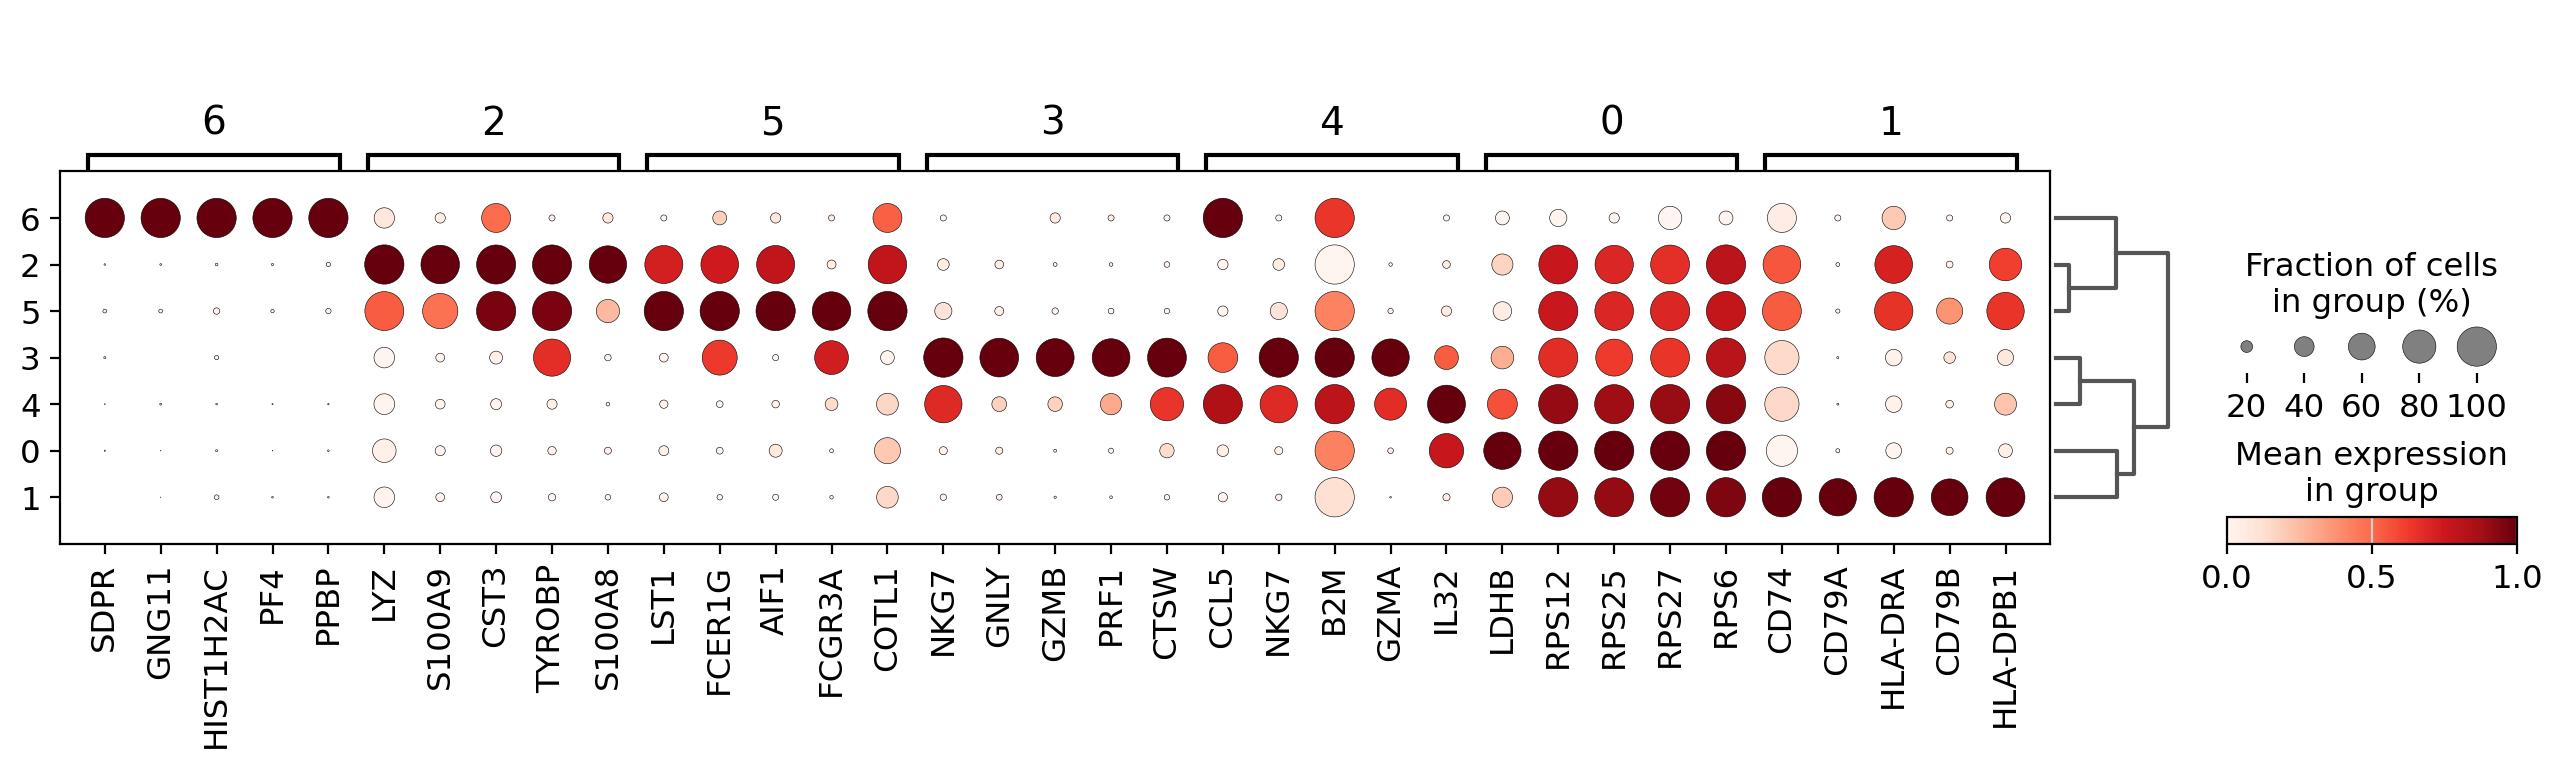


Example marker results:


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,LDHB,32.224251,2.713454,8.075135e-228,1.102740e-223,0.933810,0.484868
1,0,RPS12,31.484327,1.025044,1.423638e-217,9.720598e-214,1.000000,0.988816
2,0,RPS25,29.644430,1.143438,4.001243e-193,1.092819e-189,0.998211,0.968421
3,0,RPS27,28.922407,1.000290,6.241748e-184,1.420622e-180,0.999106,0.989474
8,0,CD3D,27.379066,3.107327,4.869521e-165,5.115244e-162,0.875671,0.258553
13656,1,CD74,29.051130,4.078282,1.489020e-185,2.033406e-181,1.000000,0.820681
13657,1,CD79A,27.865353,7.769332,7.019277e-171,4.792763e-167,0.933526,0.041012
13658,1,HLA-DRA,27.678810,4.886109,1.256440e-168,5.719314e-165,1.000000,0.493892
13659,1,CD79B,26.574320,5.520246,1.344883e-155,4.591429e-152,0.913295,0.141361
13660,1,HLA-DPB1,25.882404,4.037180,1.050996e-147,2.870479e-144,0.985549,0.448080


In [12]:
# ``rank_genes_groups`` compares each cluster with the remaining cells. We use
# the Wilcoxon rank-sum method and the normalized/log-transformed full-gene matrix
# stored in ``adata.raw``. The output is useful for characterizing clusters.
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    use_raw=True,
    pts=True,
    key_added="markers_leiden",
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="leiden",
    key="markers_leiden",
    n_genes=5,
    standard_scale="var",
    show=False,
)
save_and_show("12_top_markers_per_cluster.png")


# Convert Scanpy's marker result into an ordinary DataFrame and save it. ``group``
# identifies the Leiden cluster associated with each ranked gene.
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key="markers_leiden",
)

markers.to_csv(TABLE_DIR / "all_cluster_marker_genes.csv", index=False)


# This filtered table is convenient for manual inspection, but cutoffs should be
# interpreted descriptively rather than as definitive biological thresholds.
marker_candidates = markers.loc[
    (markers["pvals_adj"] < 0.05)
    & (markers["logfoldchanges"].fillna(-np.inf) > 1.0)
].copy()

marker_candidates.to_csv(
    TABLE_DIR / "filtered_cluster_marker_candidates.csv",
    index=False,
)

print("\nExample marker results:")
display(marker_candidates.groupby("group", observed=True).head(5))


# Critical statistical warning:
# every cell belongs to the same donor, so cells are not independent biological
# replicates. Extremely small p-values do not establish population-level effects.
# Here, marker ranking is used only to describe clusters, not to claim differential
# expression between clinical groups.

# 12. Inspect known lineage and cell-type markers

Marker genes absent from the expression matrix:


CD4/naive T cells    [TRAC]
Cytotoxic T cells    [TRAC]
Name: missing_markers, dtype: object

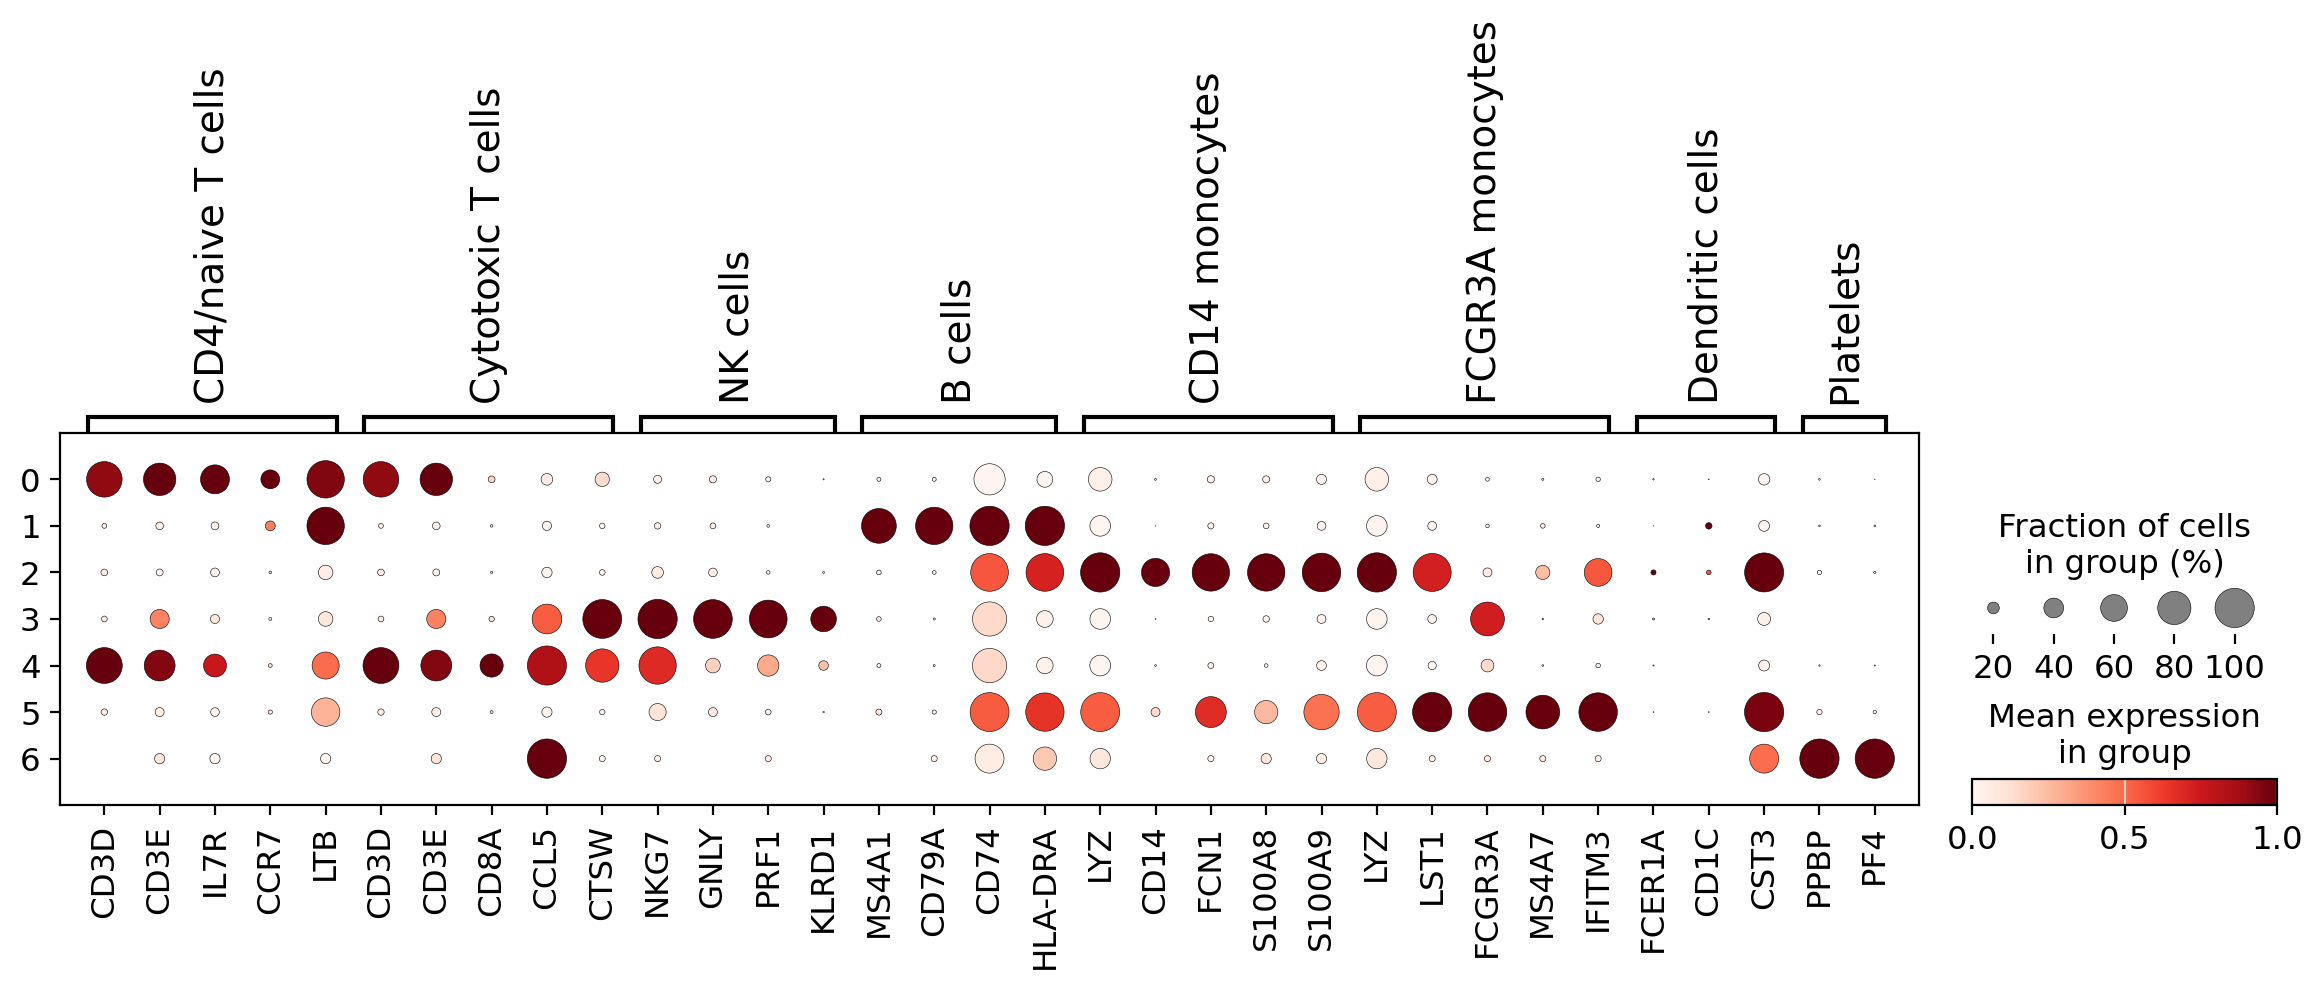

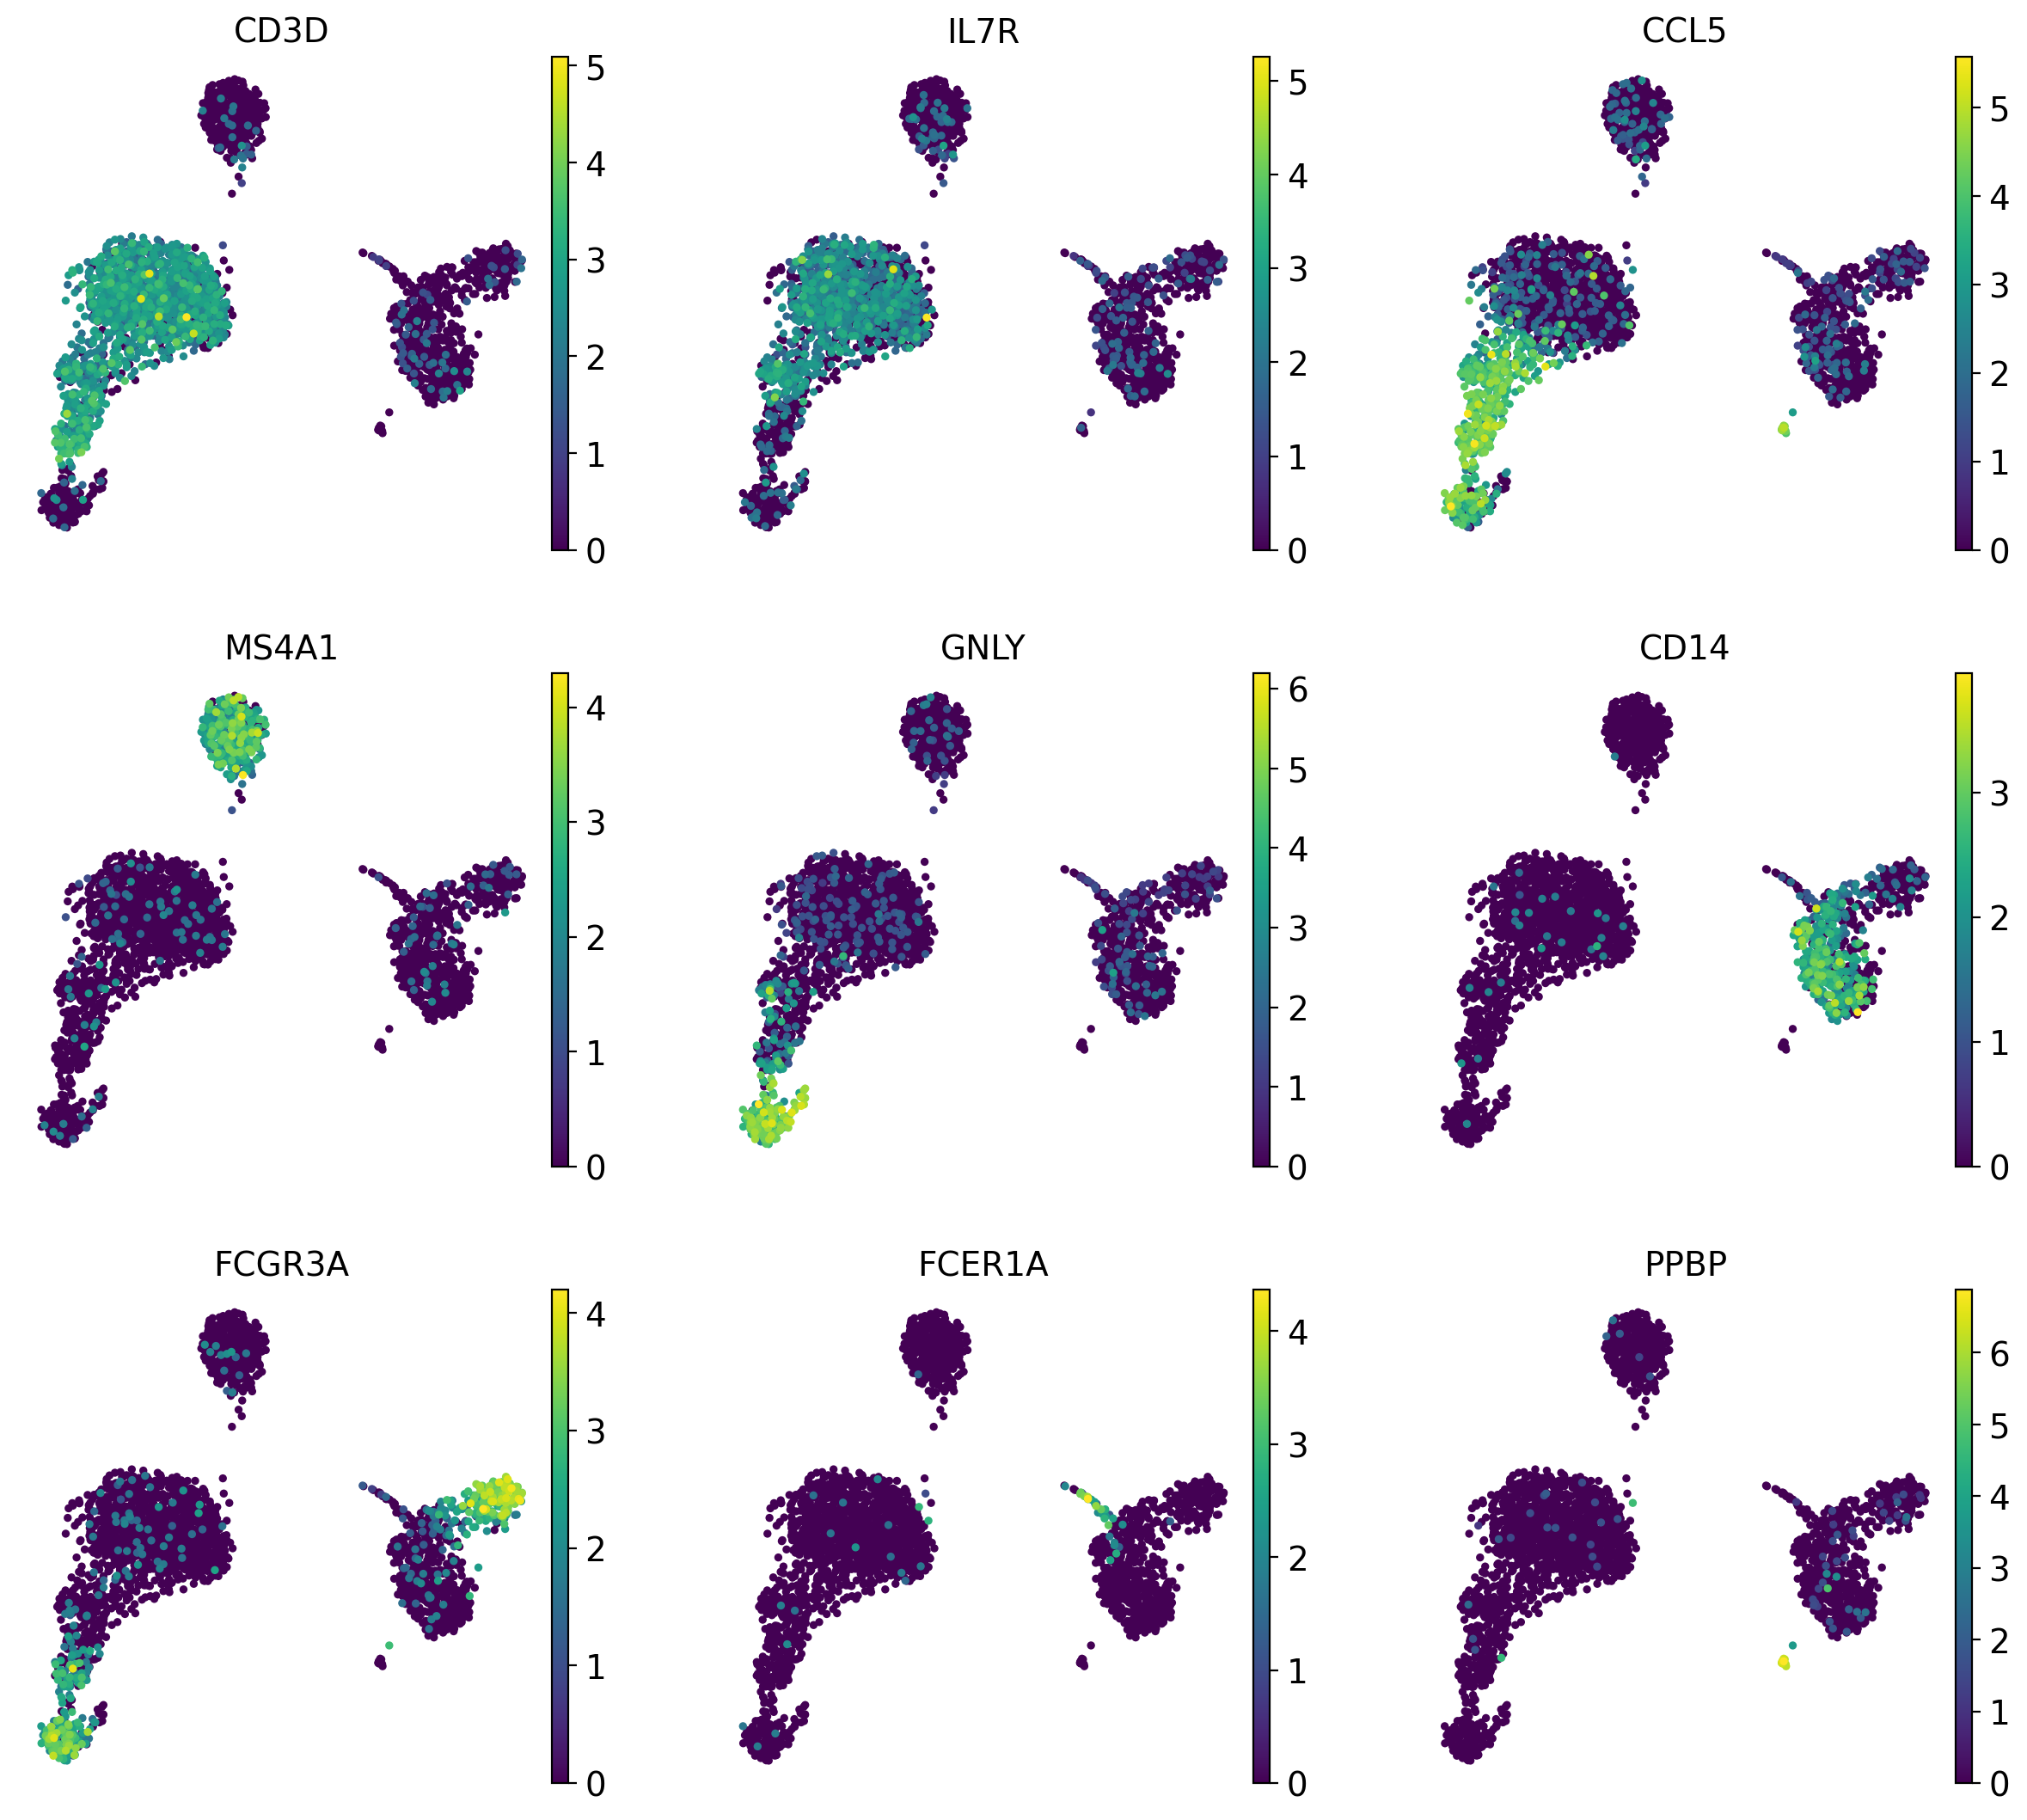

In [14]:
# Cell-type annotation should use combinations of positive and negative markers,
# not a single gene. Cytotoxic T cells and NK cells, for example, both express
# NKG7; expression of CD3D/CD3E/TRAC helps identify the T-cell lineage.
CELL_TYPE_MARKERS = {
    "CD4/naive T cells": ["CD3D", "CD3E", "TRAC", "IL7R", "CCR7", "LTB"],
    "Cytotoxic T cells": ["CD3D", "CD3E", "TRAC", "CD8A", "CCL5", "CTSW"],
    "NK cells": ["NKG7", "GNLY", "PRF1", "KLRD1"],
    "B cells": ["MS4A1", "CD79A", "CD74", "HLA-DRA"],
    "CD14 monocytes": ["LYZ", "CD14", "FCN1", "S100A8", "S100A9"],
    "FCGR3A monocytes": ["LYZ", "LST1", "FCGR3A", "MS4A7", "IFITM3"],
    "Dendritic cells": ["FCER1A", "CD1C", "CST3"],
    "Platelets": ["PPBP", "PF4"],
}

# When use_raw=True, Scanpy searches for genes in adata.raw.var_names.
# Some markers may be absent because datasets can use different gene annotations.
expression_gene_index = (
    adata.raw.var_names
    if adata.raw is not None
    else adata.var_names
)

CELL_TYPE_MARKERS_AVAILABLE = {}
missing_marker_genes = {}

for cell_type, requested_genes in CELL_TYPE_MARKERS.items():
    available_genes = [
        gene
        for gene in requested_genes
        if gene in expression_gene_index
    ]

    missing_genes = [
        gene
        for gene in requested_genes
        if gene not in expression_gene_index
    ]

    if available_genes:
        CELL_TYPE_MARKERS_AVAILABLE[cell_type] = available_genes

    if missing_genes:
        missing_marker_genes[cell_type] = missing_genes

print("Marker genes absent from the expression matrix:")

if missing_marker_genes:
    display(pd.Series(
        missing_marker_genes,
        name="missing_markers",
    ))
else:
    print("None")


sc.pl.dotplot(
    adata,
    CELL_TYPE_MARKERS_AVAILABLE,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    show=False,
)
save_and_show("13_known_markers_by_leiden_cluster.png")


genes_for_umap = [
    "CD3D",
    "IL7R",
    "CCL5",
    "MS4A1",
    "GNLY",
    "CD14",
    "FCGR3A",
    "FCER1A",
    "PPBP",
]

genes_for_umap = [gene for gene in genes_for_umap if gene in adata.raw.var_names]

sc.pl.umap(
    adata,
    color=genes_for_umap,
    use_raw=True,
    ncols=3,
    show=False,
)
save_and_show("14_known_marker_expression_on_umap.png")

# 13. Generate provisional marker-score annotations

computing score 'annotation_score_00'
    finished (0:00:00)
computing score 'annotation_score_01'
    finished (0:00:00)
computing score 'annotation_score_02'
    finished (0:00:00)
computing score 'annotation_score_03'
    finished (0:00:00)
computing score 'annotation_score_04'
    finished (0:00:00)
computing score 'annotation_score_05'
    finished (0:00:00)
computing score 'annotation_score_06'
    finished (0:00:00)
computing score 'annotation_score_07'
    finished (0:00:00)

Mean marker-set scores by Leiden cluster:


,CD4/naive T cells,Cytotoxic T cells,NK cells,B cells,CD14 monocytes,FCGR3A monocytes,Dendritic cells,Platelets
leiden,,,,,,,,
0,0.814961,0.112532,-0.448181,-0.511364,-0.594292,-0.363537,-0.343724,-0.036883
1,-0.105817,-0.632378,-0.449673,2.616863,-0.540411,-0.292492,-0.262052,-0.033850
2,-0.877817,-0.772977,-0.520059,0.658902,2.537277,1.331486,0.886620,0.016817
3,-0.622291,0.400489,2.709222,-0.371108,-0.690103,-0.044890,-0.317543,-0.066002
4,0.407394,1.277224,0.743591,-0.380400,-0.627809,-0.383135,-0.338570,-0.032680
5,-0.868460,-0.898565,-0.556692,0.483303,0.607159,2.064519,0.721791,0.019621
6,-0.328399,0.593878,-0.281395,0.180440,0.040663,0.023926,0.411082,5.488303



Provisional automatic cluster annotations:


0    CD4/naive T cells
1              B cells
2       CD14 monocytes
3             NK cells
4    Cytotoxic T cells
5     FCGR3A monocytes
6            Platelets
Name: provisional_cell_type, dtype: object


Final cell-type labels currently used:


cell_type
CD4/naive T cells    1118
CD14 monocytes        516
B cells               346
Cytotoxic T cells     335
FCGR3A monocytes      157
NK cells              154
Platelets              12
Name: count, dtype: int64

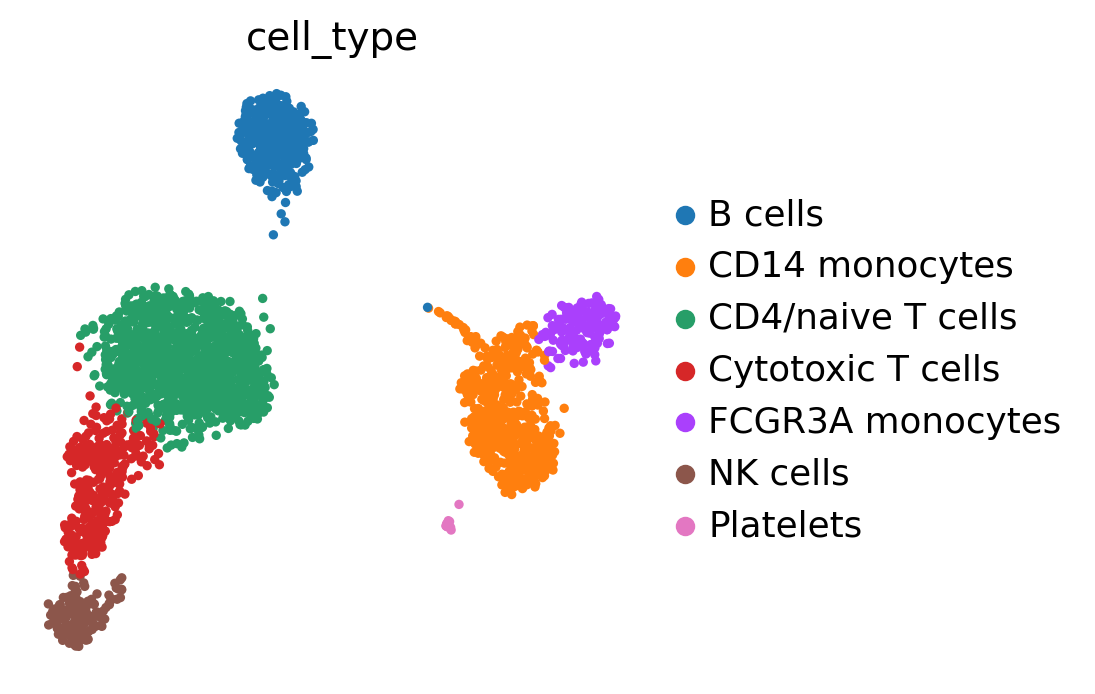

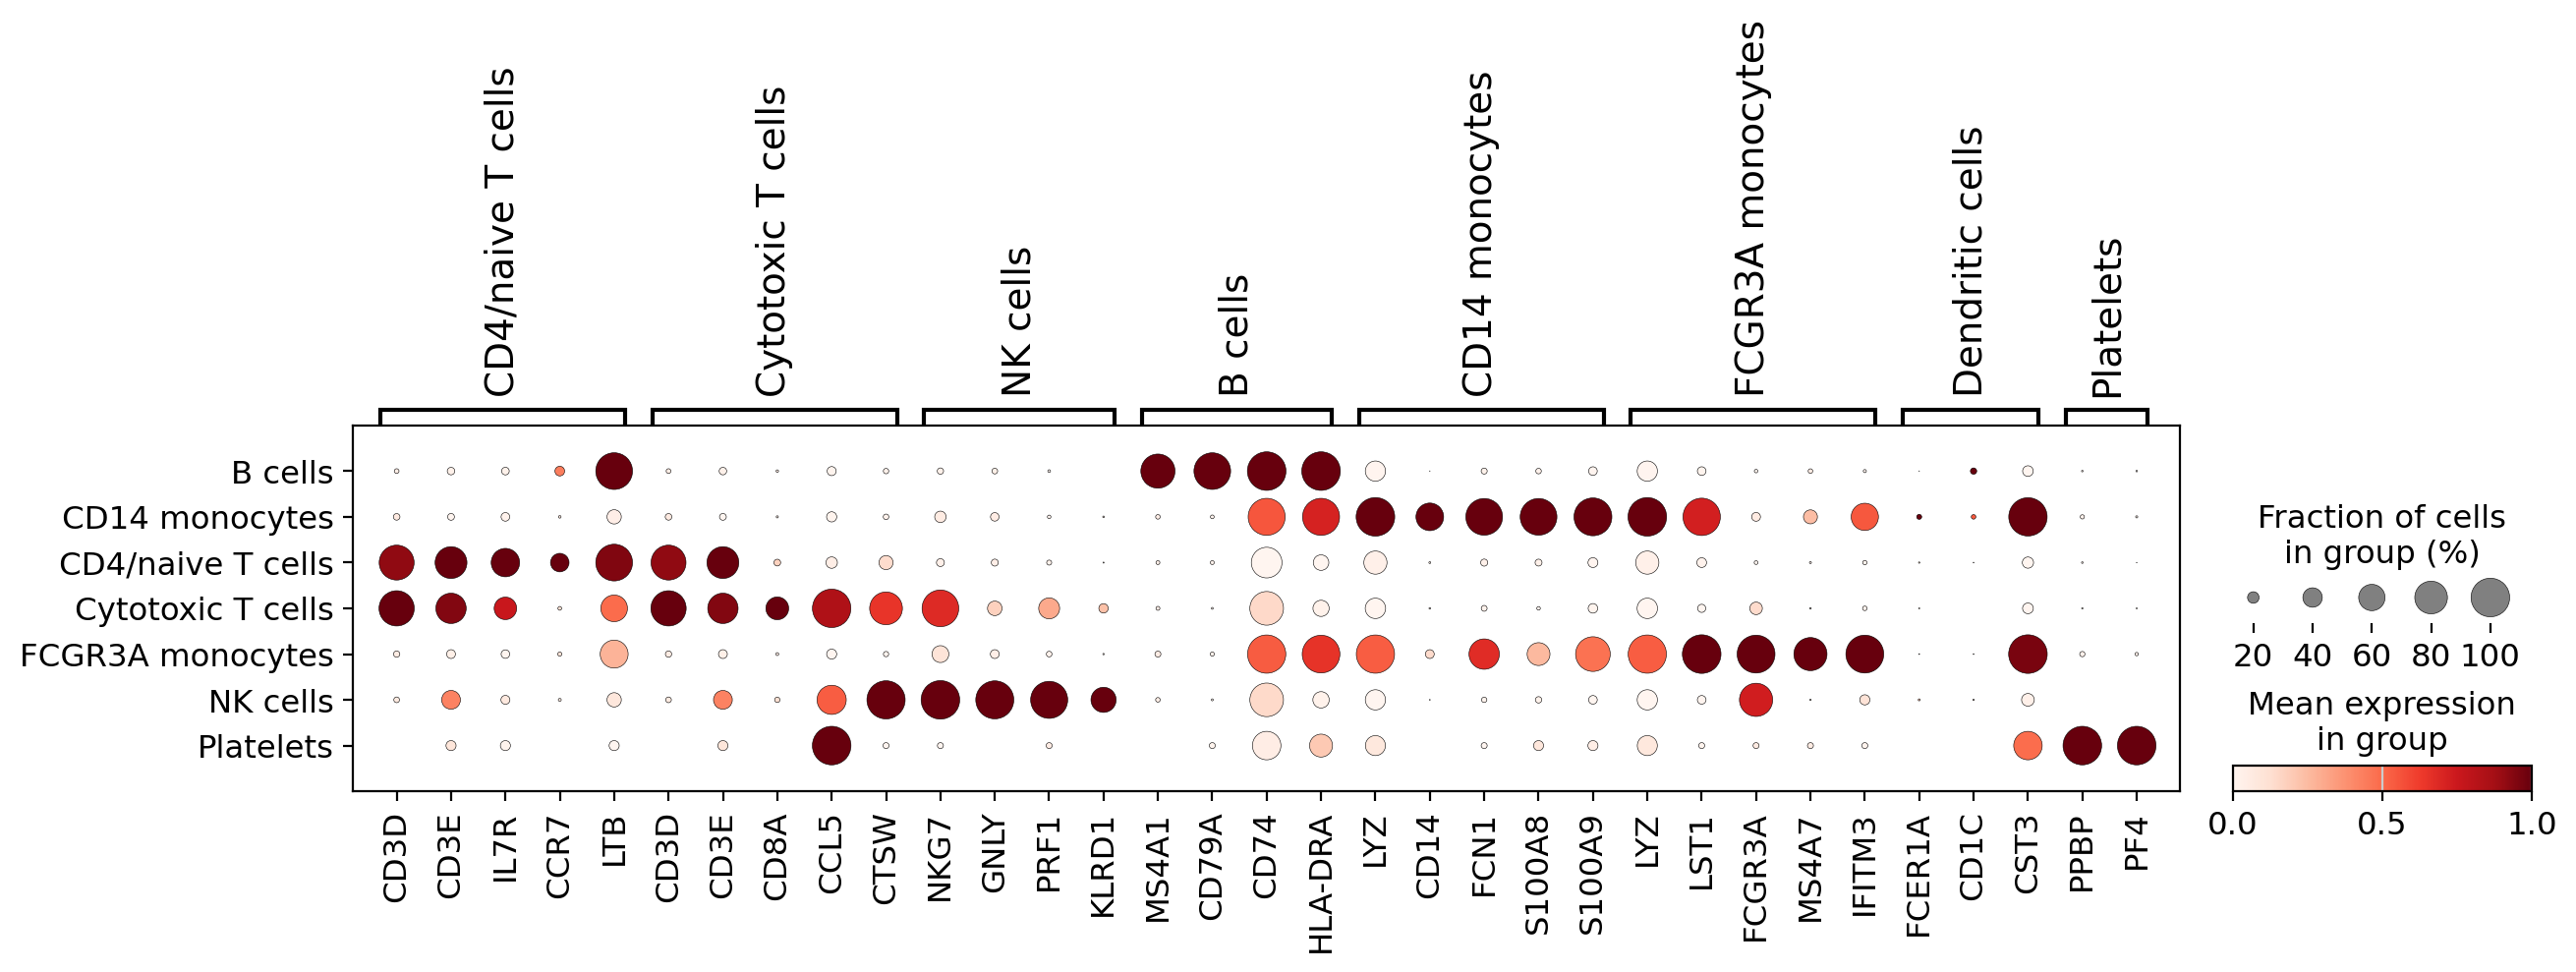

In [16]:
# The following section produces a provisional annotation so that the whole script
# can run from start to finish. It calculates a marker-set score for every cell,
# averages each score within each cluster, and assigns the highest-scoring label.
#
# This is a starting hypothesis, not a substitute for biological review. Before
# publishing the repository, inspect the dotplot, the cluster marker table and the
# UMAP gene-expression plots, then enter manual cluster labels below.
annotation_score_to_cell_type = {}

for index, (cell_type, requested_genes) in enumerate(CELL_TYPE_MARKERS.items()):
    available_genes = [
        gene for gene in requested_genes if gene in adata.raw.var_names
    ]

    if len(available_genes) < 2:
        print(
            f"Skipping provisional score for {cell_type}: "
            "fewer than two markers are available."
        )
        continue

    score_name = f"annotation_score_{index:02d}"

    sc.tl.score_genes(
        adata,
        gene_list=available_genes,
        score_name=score_name,
        use_raw=True,
        ctrl_as_ref=False,
        random_state=RANDOM_STATE,
    )

    annotation_score_to_cell_type[score_name] = cell_type


annotation_score_columns = list(annotation_score_to_cell_type)

cluster_score_table = (
    adata.obs.groupby("leiden", observed=True)[annotation_score_columns]
    .mean()
)

cluster_score_table_named = cluster_score_table.rename(
    columns=annotation_score_to_cell_type
)

cluster_score_table_named.to_csv(
    TABLE_DIR / "provisional_annotation_scores_by_cluster.csv"
)

print("\nMean marker-set scores by Leiden cluster:")
display(cluster_score_table_named)


automatic_cluster_to_cell_type = {}

for cluster, score_row in cluster_score_table.iterrows():
    best_score_column = score_row.idxmax()
    automatic_cluster_to_cell_type[str(cluster)] = (
        annotation_score_to_cell_type[best_score_column]
    )

print("\nProvisional automatic cluster annotations:")
display(pd.Series(automatic_cluster_to_cell_type, name="provisional_cell_type"))


# MANUAL REVIEW REQUIRED
# ----------------------
# After inspecting figures 12-14 and the marker tables, enter corrections here.
# You can override all clusters or only the clusters that the automatic method
# assigned incorrectly. Cluster identifiers are strings such as "0", "1", etc.
#
# Example syntax only (do not copy labels without checking your own results):
# MANUAL_CLUSTER_TO_CELL_TYPE = {
#     "0": "CD4/naive T cells",
#     "1": "CD14 monocytes",
# }
MANUAL_CLUSTER_TO_CELL_TYPE = {
    # Add reviewed cluster-to-cell-type assignments here.
}


cluster_identifiers = adata.obs["leiden"].astype(str)
final_cell_type_labels = [
    MANUAL_CLUSTER_TO_CELL_TYPE.get(
        cluster,
        automatic_cluster_to_cell_type.get(cluster, "Unassigned"),
    )
    for cluster in cluster_identifiers
]

adata.obs["cell_type"] = pd.Categorical(final_cell_type_labels)


print("\nFinal cell-type labels currently used:")
display(adata.obs["cell_type"].value_counts())


sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="right margin",
    show=False,
)
save_and_show("15_umap_cell_type_annotations.png")


# Validate the final labels by plotting marker expression again, now grouped by
# cell type rather than by an arbitrary cluster number.
sc.pl.dotplot(
    adata,
    CELL_TYPE_MARKERS_AVAILABLE,
    groupby="cell_type",
    use_raw=True,
    standard_scale="var",
    show=False,
)
save_and_show("16_marker_validation_by_cell_type.png")


# 14. Score myeloid identity and exploratory inflammatory programs


myeloid_identity_score
Available genes: ['LST1', 'TYROBP', 'FCER1G', 'CTSS', 'LILRB1']
Missing genes: []
computing score 'myeloid_identity_score'
    finished (0:00:00)

inflammatory_response_score
Available genes: ['IL1B', 'TNF', 'NFKBIA', 'TNFAIP3', 'CCL3', 'FOS', 'JUN']
Missing genes: ['CXCL8']
computing score 'inflammatory_response_score'
    finished (0:00:00)


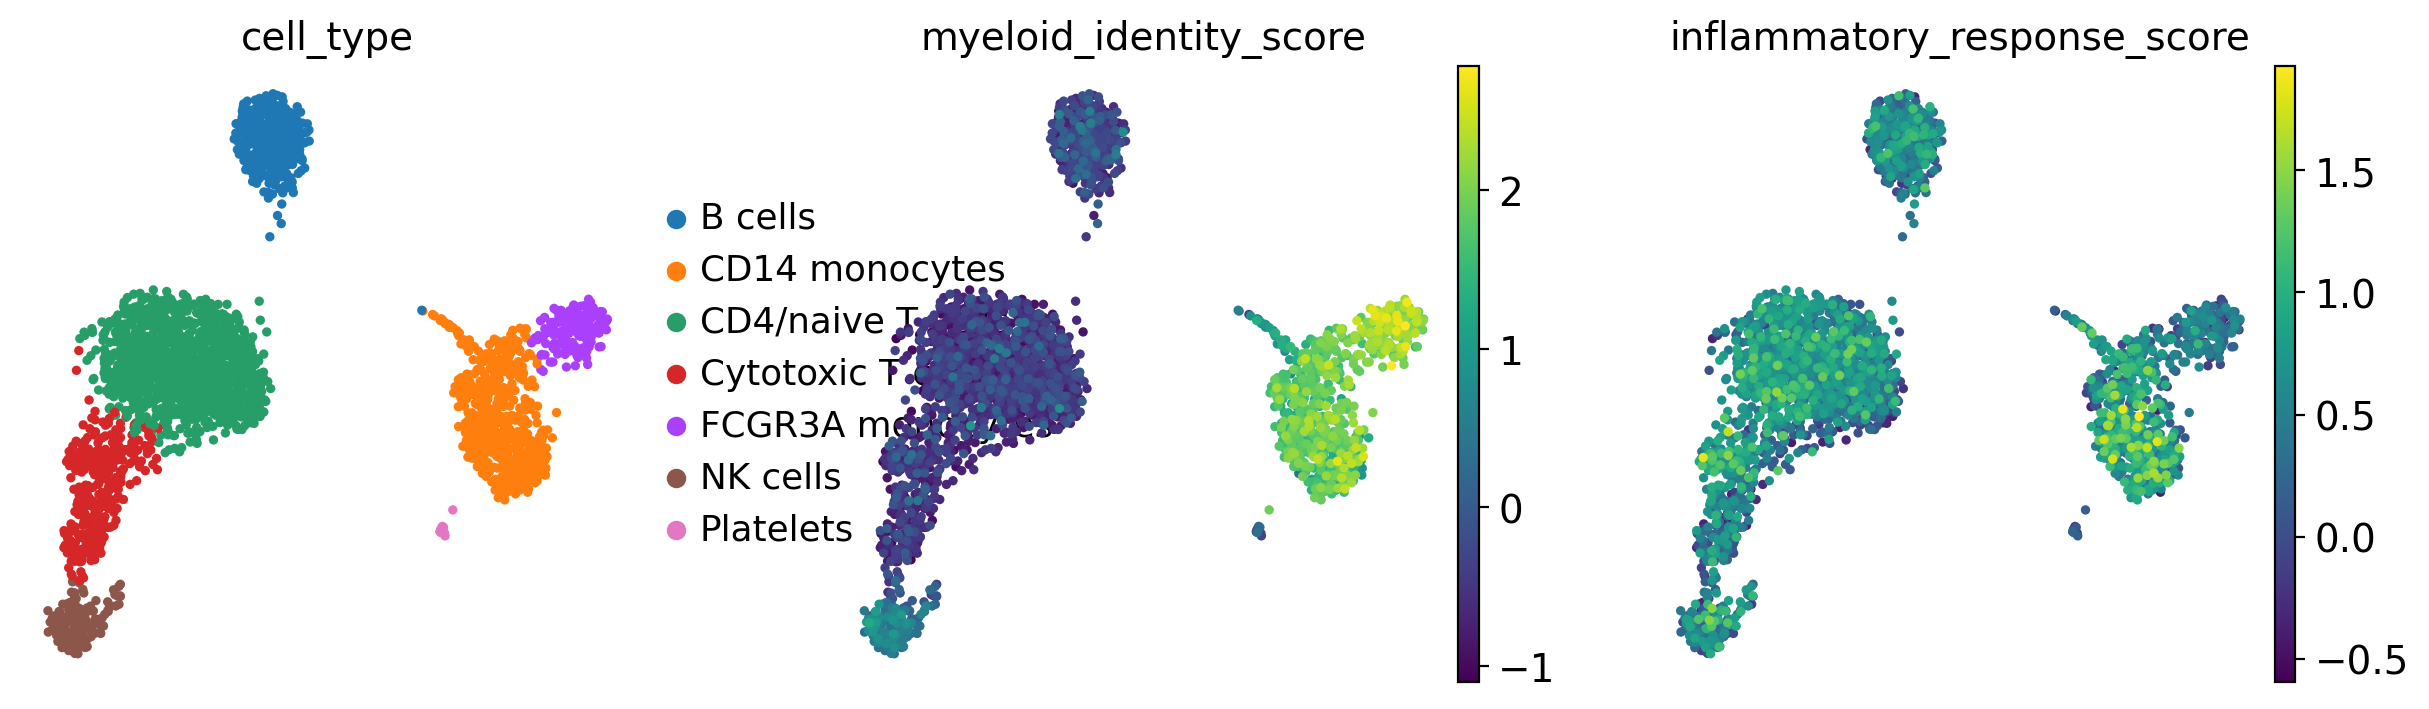

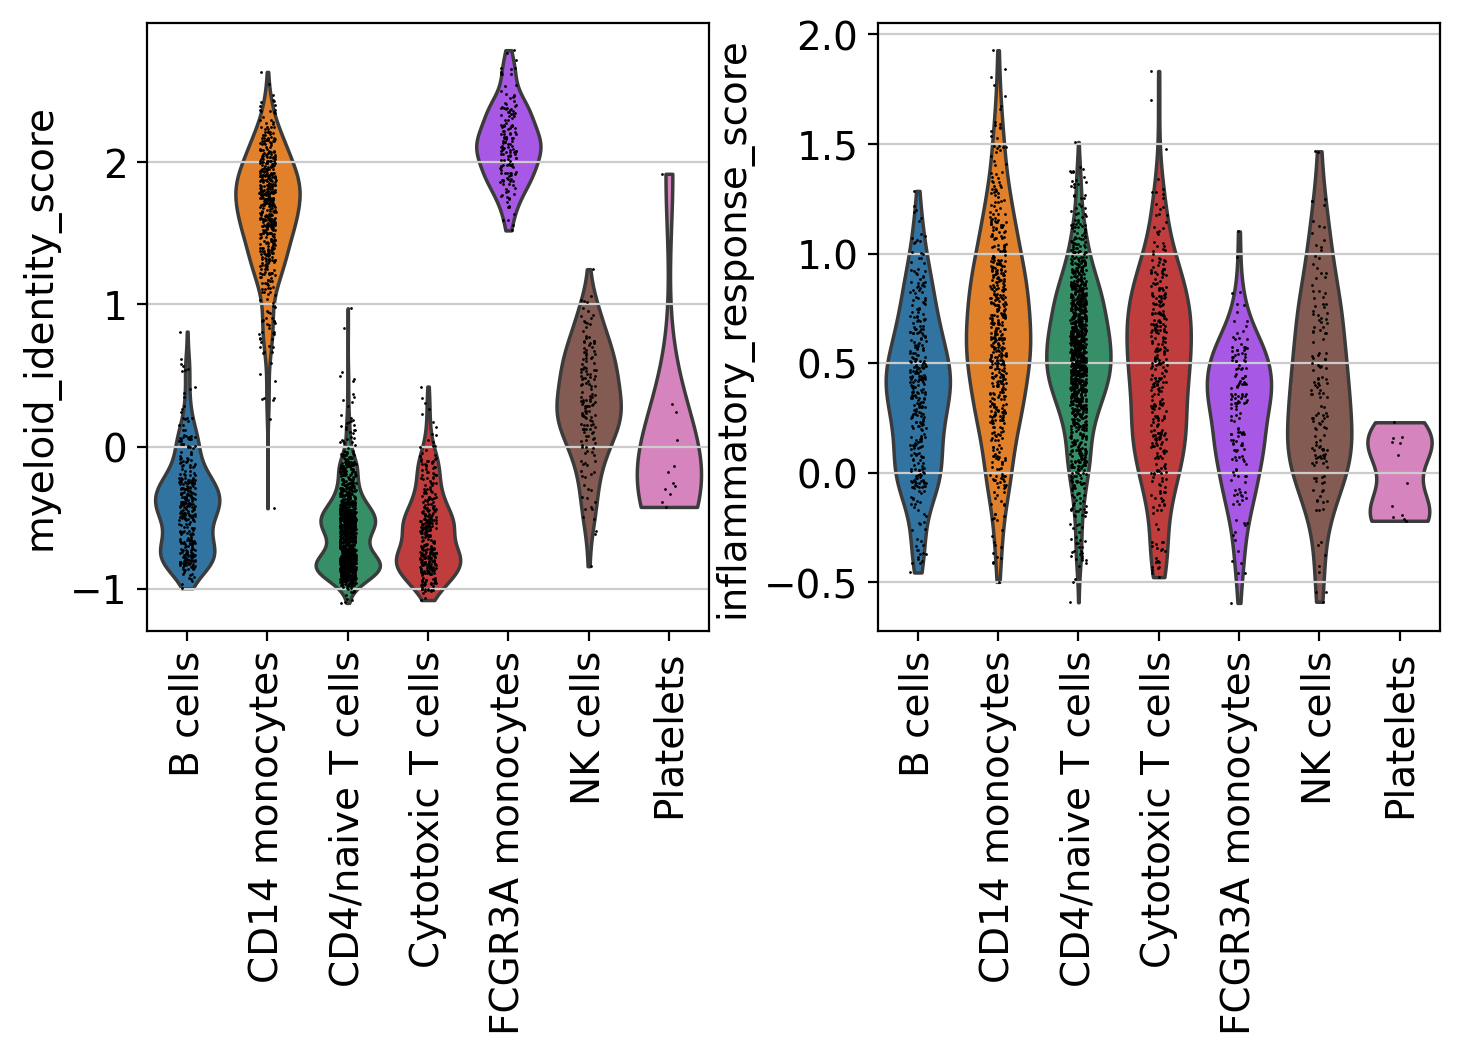

In [17]:
# Separating identity from state is conceptually important. A myeloid identity
# score asks whether a cell has a monocyte-like transcriptional program. An
# inflammatory-response score asks whether selected response genes are relatively
# elevated. These transparent, small gene lists are educational rather than a
# definitive pathway-analysis method.
BIOLOGICAL_GENE_SETS = {
    "myeloid_identity_score": [
        "LST1",
        "TYROBP",
        "FCER1G",
        "CTSS",
        "LILRB1",
    ],
    "inflammatory_response_score": [
        "IL1B",
        "TNF",
        "NFKBIA",
        "TNFAIP3",
        "CXCL8",
        "CCL3",
        "FOS",
        "JUN",
    ],
}

calculated_biological_scores = []

for score_name, requested_genes in BIOLOGICAL_GENE_SETS.items():
    available_genes = [
        gene for gene in requested_genes if gene in adata.raw.var_names
    ]
    missing_genes = sorted(set(requested_genes) - set(available_genes))

    print(f"\n{score_name}")
    print(f"Available genes: {available_genes}")
    print(f"Missing genes: {missing_genes}")

    if len(available_genes) < 2:
        print("Score skipped because fewer than two genes are available.")
        continue

    sc.tl.score_genes(
        adata,
        gene_list=available_genes,
        score_name=score_name,
        use_raw=True,
        ctrl_as_ref=False,
        random_state=RANDOM_STATE,
    )

    calculated_biological_scores.append(score_name)


sc.pl.umap(
    adata,
    color=["cell_type", *calculated_biological_scores],
    ncols=3,
    show=False,
)
save_and_show("17_umap_biological_gene_set_scores.png")


sc.pl.violin(
    adata,
    keys=calculated_biological_scores,
    groupby="cell_type",
    rotation=90,
    multi_panel=True,
    show=False,
)
save_and_show("18_biological_scores_by_cell_type.png")


# Interpretation warning:
# S100A8/S100A9-like innate signals, immediate-early genes such as FOS/JUN and
# stress-associated genes can reflect cell identity, sample processing or genuine
# activation. A score localizing to monocytes is biologically plausible, but this
# single healthy donor cannot establish cardiovascular inflammation or causality.


# 15. Summarize cell-type abundance descriptively


Descriptive cell-type summary:


,cell_type,n_cells,fraction
0,CD4/naive T cells,1118,0.423806
1,CD14 monocytes,516,0.195603
2,B cells,346,0.131160
3,Cytotoxic T cells,335,0.126990
4,FCGR3A monocytes,157,0.059515
5,NK cells,154,0.058378
6,Platelets,12,0.004549


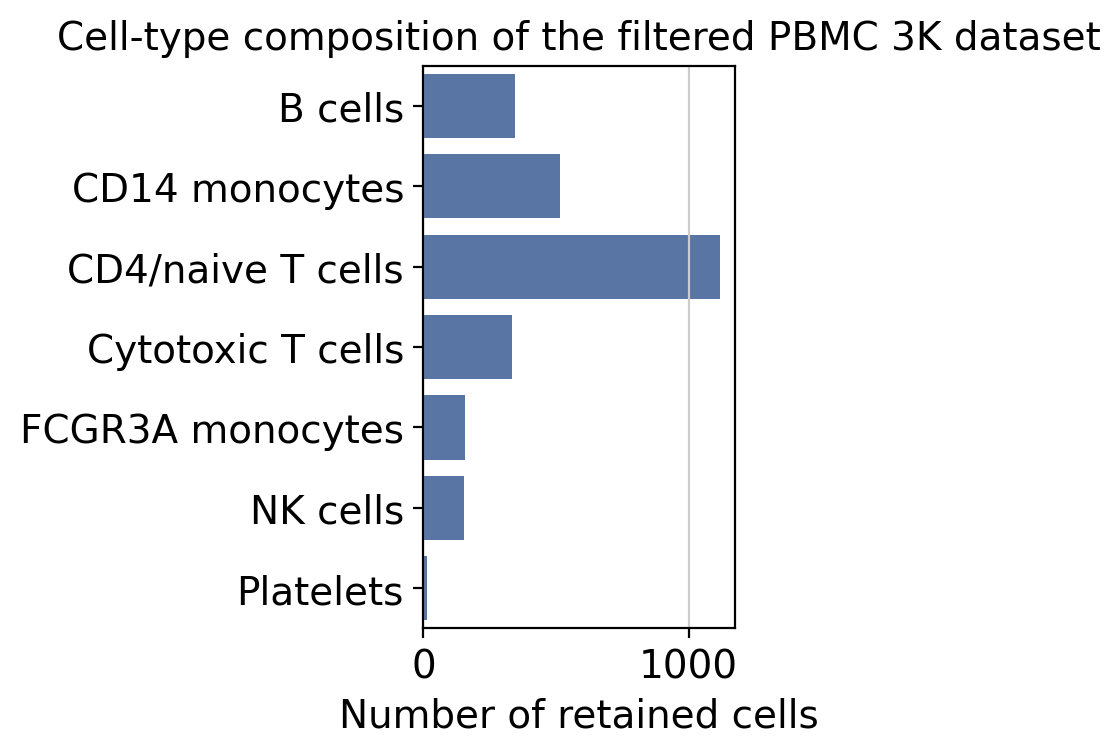

In [18]:
cell_type_summary = (
    adata.obs["cell_type"]
    .value_counts()
    .rename_axis("cell_type")
    .reset_index(name="n_cells")
)

cell_type_summary["fraction"] = (
    cell_type_summary["n_cells"] / cell_type_summary["n_cells"].sum()
)

cell_type_summary.to_csv(
    TABLE_DIR / "cell_type_summary.csv",
    index=False,
)

print("\nDescriptive cell-type summary:")
display(cell_type_summary)


sns.barplot(
    data=cell_type_summary,
    x="n_cells",
    y="cell_type",
    color="#4C72B0",
)
plt.xlabel("Number of retained cells")
plt.ylabel("")
plt.title("Cell-type composition of the filtered PBMC 3K dataset")
plt.tight_layout()
save_and_show("19_cell_type_counts.png")


# These fractions describe the cells retained by this technical workflow. They
# should not be interpreted as unbiased population frequencies because capture,
# survival, sequencing depth and filtering can all change observed proportions.


# 16. Save the processed object, parameters and final checks

In [19]:
PROCESSED_DATA_FILE = RESULTS_DIR / "pbmc3k_processed.h5ad"
adata.write_h5ad(PROCESSED_DATA_FILE, compression="gzip")


analysis_parameters = pd.Series(
    {
        "random_state": RANDOM_STATE,
        "min_genes_per_cell": MIN_GENES,
        "max_genes_per_cell": MAX_GENES,
        "max_mitochondrial_percent": MAX_MITOCHONDRIAL_PERCENT,
        "min_cells_per_gene": MIN_CELLS_PER_GENE,
        "remove_predicted_doublets": REMOVE_PREDICTED_DOUBLETS,
        "n_highly_variable_genes": number_of_hvgs,
        "n_neighbors": N_NEIGHBORS,
        "n_pcs_for_neighbors": N_PCS_FOR_NEIGHBORS,
        "selected_clustering": SELECTED_CLUSTERING,
        "final_number_of_cells": adata.n_obs,
        "final_number_of_genes": adata.n_vars,
    },
    name="value",
)

analysis_parameters.to_csv(TABLE_DIR / "analysis_parameters.csv")


print("\nAnalysis complete.")
print(f"Processed AnnData: {PROCESSED_DATA_FILE}")
print(f"Figures directory: {FIGURE_DIR}")
print(f"Tables directory: {TABLE_DIR}")
print("\nFinal AnnData structure:")
print(adata)



Analysis complete.
Processed AnnData: /home/alejandro/sc-RNA/results/pbmc3k_processed.h5ad
Figures directory: /home/alejandro/sc-RNA/results/figures
Tables directory: /home/alejandro/sc-RNA/results/tables

Final AnnData structure:
AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'leiden_r03', 'leiden_r05', 'leiden_r08', 'leiden_r10', 'leiden', 'annotation_score_00', 'annotation_score_01', 'annotation_score_02', 'annotation_score_03', 'annotation_score_04', 'annotation_score_05', 'annotation_score_06', 'annotation_score_07', 'cell_type', 'myeloid_identity_score', 'inflammatory_response_score'
    var: 'gene_ids', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1